# \(K^0_S \rightarrow \pi^+\pi^-\) daughter \(p_T\) QA

This notebook compares the two-dimensional daughter-momentum distribution:

\[
p_T^{\pi^+}\ \mathrm{vs.}\ p_T^{\pi^-}
\]

for every cut directory in the ROOT file.

For each cut it draws:

1. candidates inside the configurable \(K^0_S\) mass window;
2. candidates outside the mass window, using configurable sidebands;
3. the bin-by-bin ratio of the normalized in-window and outside-window shapes.

The preferred input histogram is:

`h3_Kshort_ptplus_vs_ptminus_vs_mass`

with axes \(p_T^+\), \(p_T^-\), and \(K^0_S\) mass. A fallback to the older
`h3_Kshort_pt1_vs_pt2_vs_mass` is provided, but those axes are track 1 and
track 2 rather than charge ordered.

In [1]:
import ROOT as root
import math
import os
from pathlib import Path

#root.gROOT.SetBatch(False)
root.gStyle.SetOptStat(0)
root.gStyle.SetPalette(root.kBird)
root.gStyle.SetNumberContours(100)
root.TH1.AddDirectory(False)

ROOT_KEEPALIVE = []

def keep(obj):
    ROOT_KEEPALIVE.append(obj)
    root.SetOwnership(obj, False)
    return obj

Welcome to JupyROOT 6.30/06


In [2]:
# -----------------------------
# User configuration
# -----------------------------

file_path = "input/"
file_name = "k0s_pp_ratio_new_vtx_1p23_1p0_1p6_000_all_2M.root"

output_dir = "output/K0S_daughter_QA"
save_individual_pdf = False
save_multipage_pdf = True
save_png = False

# Charge category. The charge-ordered histogram is filled for unlike-sign pairs.
charge_name = "unlike"

# Preferred and fallback histogram names.
preferred_hist_name = "h3_Kshort_ptplus_vs_ptminus_vs_mass"
fallback_hist_name = "h3_Kshort_pt1_vs_pt2_vs_mass"
allow_pt1_pt2_fallback = True

# K0S signal window.
mass_window = (0.475, 0.520)

# Outside region. These sidebands avoid the central peak region.
outside_sidebands = [
    (0.400, 0.460),
    (0.540, 0.600),
]

# Display range for both daughter transverse momenta.
pt_display_range = (0.0, 3.0)

# Optional 2D rebinning after projection.
rebin_x = 1
rebin_y = 1

# Ratio definition:
#   True  -> compare shapes after each 2D map is normalized to unit integral.
#   False -> raw in-window / outside counts.
normalize_before_ratio = True

# For empty denominator bins:
#   0.0 gives an empty ratio bin rather than an extreme value.
empty_denominator_value = 0.0

# Set to a list to control ordering manually.
# Use None to discover all directories beginning with "cut" or "exactCut".
cuts_to_plot = None

In [3]:
input_path = str(Path(file_path) / file_name)
input_file = root.TFile.Open(input_path)

if not input_file or input_file.IsZombie():
    raise RuntimeError(f"Cannot open ROOT file: {input_path}")

Path(output_dir).mkdir(parents=True, exist_ok=True)

print("Opened:", input_path)
print("Output:", output_dir)

Opened: input/k0s_pp_ratio_new_vtx_1p23_1p0_1p6_000_all_2M.root
Output: output/K0S_daughter_QA


In [4]:
def discover_cut_directories(root_file):
    names = []

    for key in root_file.GetListOfKeys():
        obj = key.ReadObj()

        if not obj.InheritsFrom("TDirectory"):
            continue

        name = obj.GetName()

        if name.startswith("cut") or name.startswith("exactCut"):
            names.append(name)

    def sort_key(name):
        if name.startswith("cut"):
            digits = "".join(ch for ch in name[3:] if ch.isdigit())
            number = int(digits[:2]) if len(digits) >= 2 else 999
            return (0, number, name)

        if name.startswith("exactCut"):
            digits = "".join(ch for ch in name if ch.isdigit())
            number = int(digits) if digits else 999
            return (1, number, name)

        return (2, 999, name)

    return sorted(names, key=sort_key)


if cuts_to_plot is None:
    cuts_to_plot = discover_cut_directories(input_file)

print("Cuts to plot:")
for cut in cuts_to_plot:
    print("  ", cut)

Cuts to plot:
   cut00_very_loose
   cut01_loose
   cut02_preselection
   cut03_baseline
   cut04_pairDCA_15mm
   cut05_pairDCA_10mm
   cut06_pairDCA_7mm
   cut07_pairDCA_5mm
   cut08_pairDCA_3mm
   cut09_pairDCA_2mm
   exactCut1
   exactCut2
   exactCut3


In [5]:
def get_histogram_for_cut(cut_name):
    preferred_path = f"{cut_name}/{charge_name}/{preferred_hist_name}"
    hist = input_file.Get(preferred_path)

    if hist:
        clone = hist.Clone(
            f"{preferred_hist_name}_{cut_name}_{charge_name}_clone"
        )
        clone.SetDirectory(0)
        return keep(clone), True, preferred_path

    fallback_path = f"{cut_name}/{charge_name}/{fallback_hist_name}"
    fallback = input_file.Get(fallback_path)

    if fallback and allow_pt1_pt2_fallback:
        clone = fallback.Clone(
            f"{fallback_hist_name}_{cut_name}_{charge_name}_clone"
        )
        clone.SetDirectory(0)
        return keep(clone), False, fallback_path

    raise RuntimeError(
        "Missing both preferred and fallback histograms for "
        f"{cut_name}/{charge_name}"
    )


def z_bin_range(axis, low, high):
    first = axis.FindBin(low + 1.0e-9)
    last = axis.FindBin(high - 1.0e-9)
    return first, last


def project_xy_for_mass_ranges(h3, ranges, name):
    result = None
    z_axis = h3.GetZaxis()

    # Save the original visible Z range, because Project3D uses the
    # currently selected axis range.
    original_first = z_axis.GetFirst()
    original_last = z_axis.GetLast()

    try:
        for index, (low, high) in enumerate(ranges):
            z1, z2 = z_bin_range(z_axis, low, high)
            z_axis.SetRange(z1, z2)

            # TH3::Project3D is the portable PyROOT interface.
            # "xy" keeps X = daughter pT+ (or pT1) and
            # Y = daughter pT- (or pT2).
            part = h3.Project3D("xy e")
            part.SetName(f"{name}_part{index}")
            part.SetDirectory(0)
            keep(part)

            if result is None:
                result = part.Clone(name)
                result.SetDirectory(0)
                keep(result)
            else:
                result.Add(part)

    finally:
        z_axis.SetRange(original_first, original_last)

    if result is None:
        raise RuntimeError(f"No mass ranges were projected for {name}")

    if rebin_x > 1 or rebin_y > 1:
        result.Rebin2D(rebin_x, rebin_y)

    return result


def normalize_2d(h2, name):
    result = h2.Clone(name)
    result.SetDirectory(0)
    keep(result)

    integral = result.Integral()

    if integral > 0.0:
        result.Scale(1.0 / integral)

    return result


def make_ratio_2d(numerator, denominator, name):
    ratio = numerator.Clone(name)
    ratio.SetDirectory(0)
    ratio.Reset("ICES")
    keep(ratio)

    for ix in range(1, ratio.GetNbinsX() + 1):
        for iy in range(1, ratio.GetNbinsY() + 1):
            a = numerator.GetBinContent(ix, iy)
            b = denominator.GetBinContent(ix, iy)
            ea = numerator.GetBinError(ix, iy)
            eb = denominator.GetBinError(ix, iy)

            if b <= 0.0:
                ratio.SetBinContent(ix, iy, empty_denominator_value)
                ratio.SetBinError(ix, iy, 0.0)
                continue

            value = a / b

            error2 = 0.0
            if a > 0.0:
                error2 += (ea / a) ** 2
            if b > 0.0:
                error2 += (eb / b) ** 2

            error = abs(value) * math.sqrt(error2) if error2 > 0.0 else 0.0

            ratio.SetBinContent(ix, iy, value)
            ratio.SetBinError(ix, iy, error)

    return ratio

In [6]:
def format_2d(h, x_title, y_title, z_title):
    h.SetTitle("")
    h.GetXaxis().SetTitle(x_title)
    h.GetYaxis().SetTitle(y_title)
    h.GetZaxis().SetTitle(z_title)

    h.GetXaxis().SetRangeUser(*pt_display_range)
    h.GetYaxis().SetRangeUser(*pt_display_range)

    h.GetXaxis().SetTitleSize(0.055)
    h.GetYaxis().SetTitleSize(0.055)
    h.GetZaxis().SetTitleSize(0.050)

    h.GetXaxis().SetLabelSize(0.045)
    h.GetYaxis().SetLabelSize(0.045)
    h.GetZaxis().SetLabelSize(0.040)

    h.GetXaxis().SetTitleOffset(1.00)
    h.GetYaxis().SetTitleOffset(1.05)
    h.GetZaxis().SetTitleOffset(1.15)

    h.GetXaxis().CenterTitle()
    h.GetYaxis().CenterTitle()


def draw_panel_label(text, x=0.14, y=0.94, size=0.045):
    label = keep(root.TLatex())
    label.SetNDC()
    label.SetTextFont(42)
    label.SetTextSize(size)
    label.DrawLatex(x, y, text)
    return label


def set_pad_2d():
    root.gPad.SetLeftMargin(0.13)
    root.gPad.SetBottomMargin(0.13)
    root.gPad.SetRightMargin(0.16)
    root.gPad.SetTopMargin(0.10)
    root.gPad.SetTicks(1, 1)

In [7]:
def prepare_cut_maps(cut_name):
    h3, charge_ordered, source_path = get_histogram_for_cut(cut_name)

    h_inside = project_xy_for_mass_ranges(
        h3,
        [mass_window],
        f"h_inside_{cut_name}"
    )

    h_outside = project_xy_for_mass_ranges(
        h3,
        outside_sidebands,
        f"h_outside_{cut_name}"
    )

    if normalize_before_ratio:
        h_inside_for_ratio = normalize_2d(
            h_inside,
            f"h_inside_norm_{cut_name}"
        )
        h_outside_for_ratio = normalize_2d(
            h_outside,
            f"h_outside_norm_{cut_name}"
        )
    else:
        h_inside_for_ratio = h_inside
        h_outside_for_ratio = h_outside

    h_ratio = make_ratio_2d(
        h_inside_for_ratio,
        h_outside_for_ratio,
        f"h_ratio_{cut_name}"
    )

    return {
        "cut": cut_name,
        "h3": h3,
        "inside": h_inside,
        "outside": h_outside,
        "inside_ratio_input": h_inside_for_ratio,
        "outside_ratio_input": h_outside_for_ratio,
        "ratio": h_ratio,
        "charge_ordered": charge_ordered,
        "source_path": source_path,
    }


cut_maps = []

for cut_name in cuts_to_plot:
    try:
        cut_maps.append(prepare_cut_maps(cut_name))
    except RuntimeError as error:
        print("Skipping:", error)

print("Prepared", len(cut_maps), "cuts")

Prepared 13 cuts


## Per-cut daughter QA

Each canvas contains three panels:

- left: \(p_T^+\) versus \(p_T^-\) inside the \(K^0_S\) mass window;
- middle: the same distribution in the outside sidebands;
- right: inside/outside.

When `normalize_before_ratio = True`, the ratio compares distribution shapes rather
than raw populations.

Finished per-cut daughter QA


Info in <TCanvas::Print>: pdf file output/K0S_daughter_QA/K0S_daughter_pt_QA_all_cuts.pdf has been created using the current canvas
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_pt_QA_all_cuts.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_pt_QA_all_cuts.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_pt_QA_all_cuts.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_pt_QA_all_cuts.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_pt_QA_all_cuts.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_pt_QA_all_cuts.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_pt_QA_all_cuts.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_

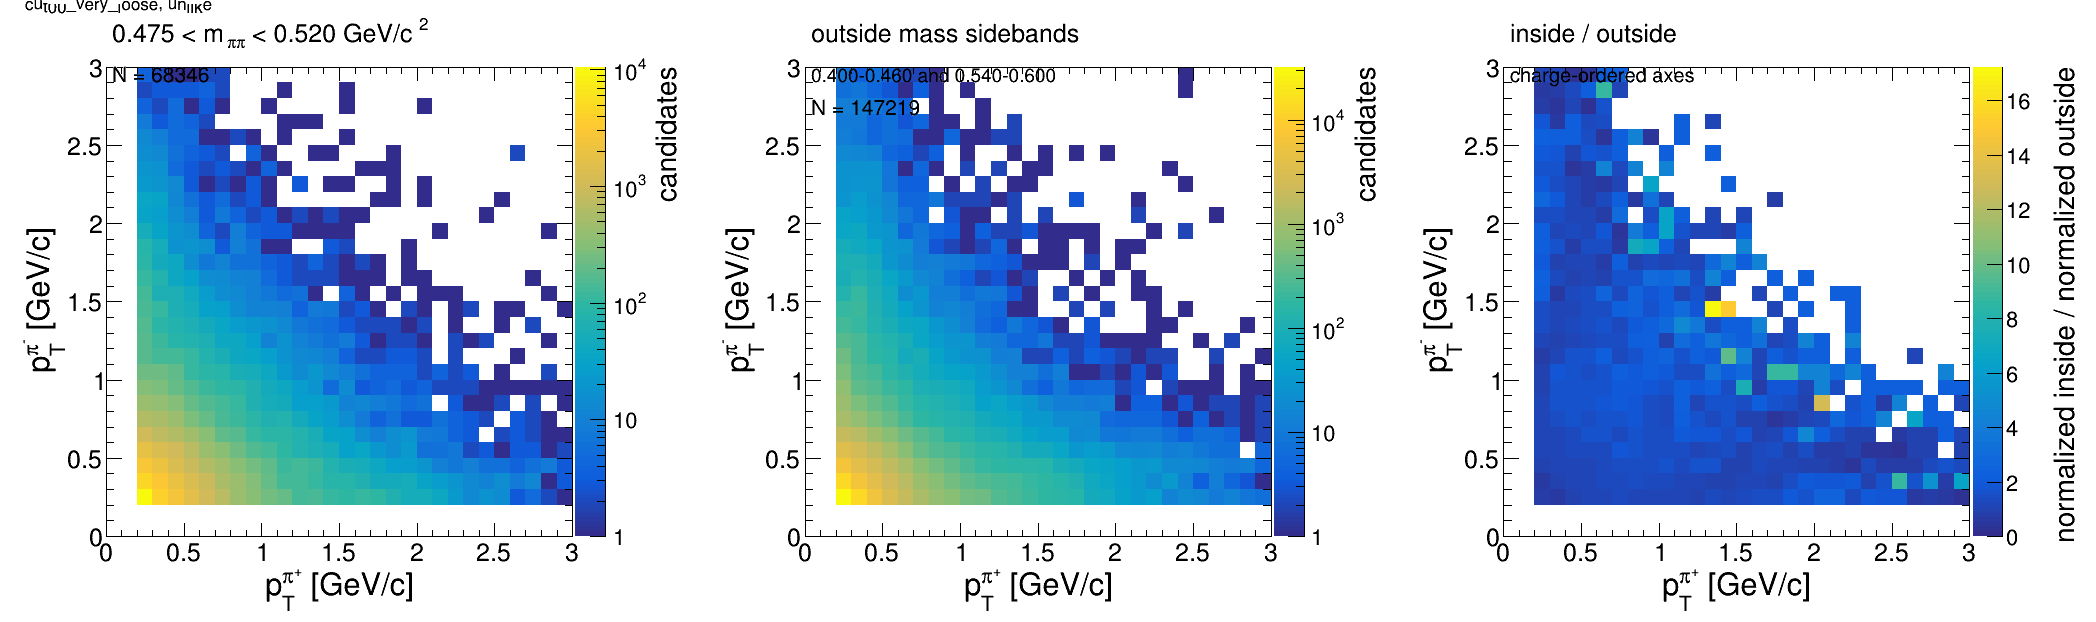

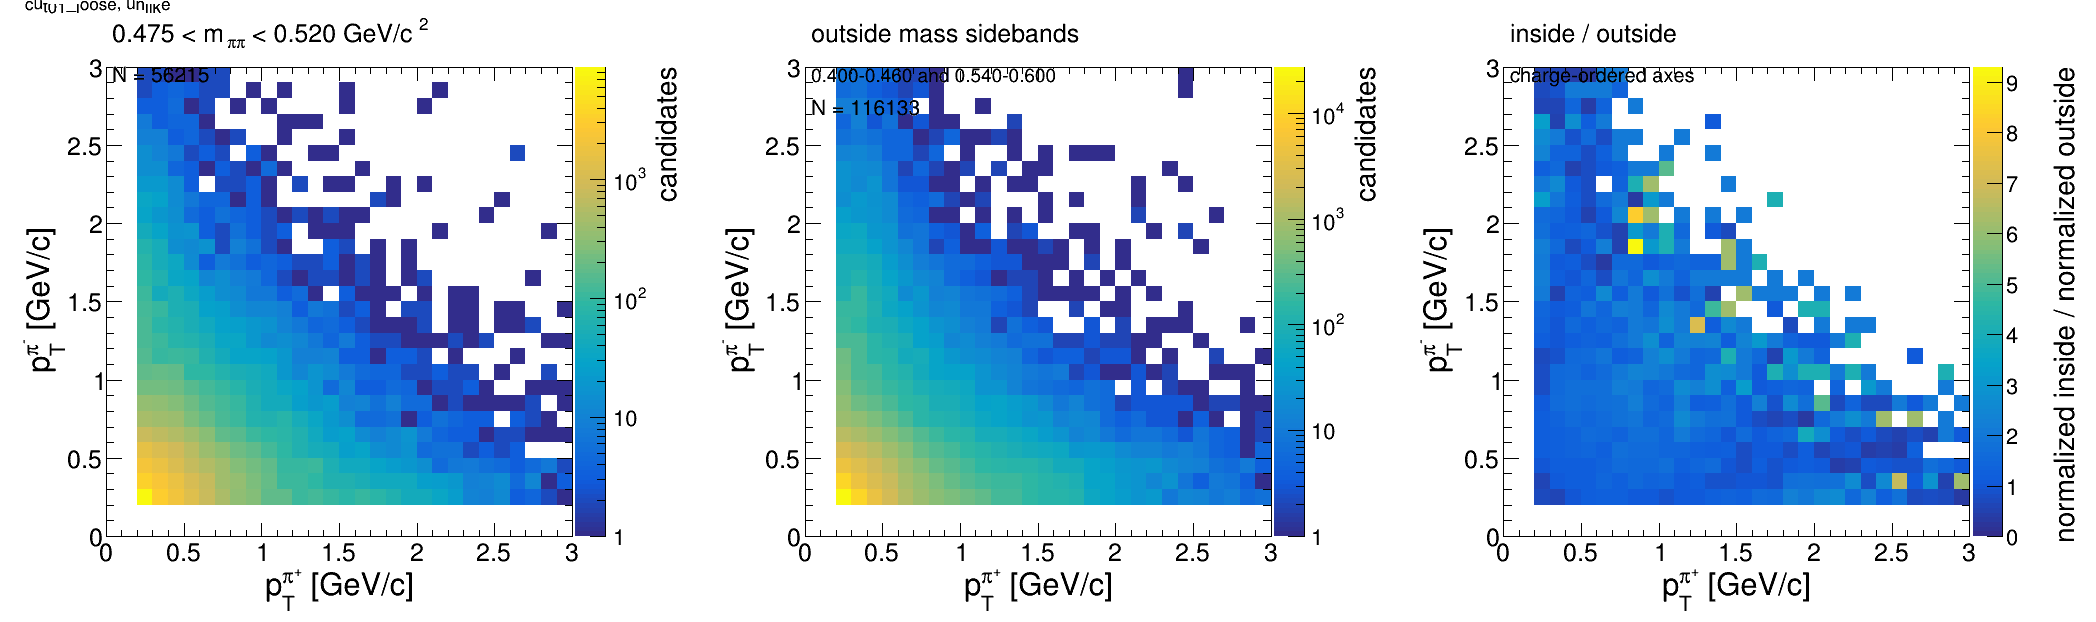

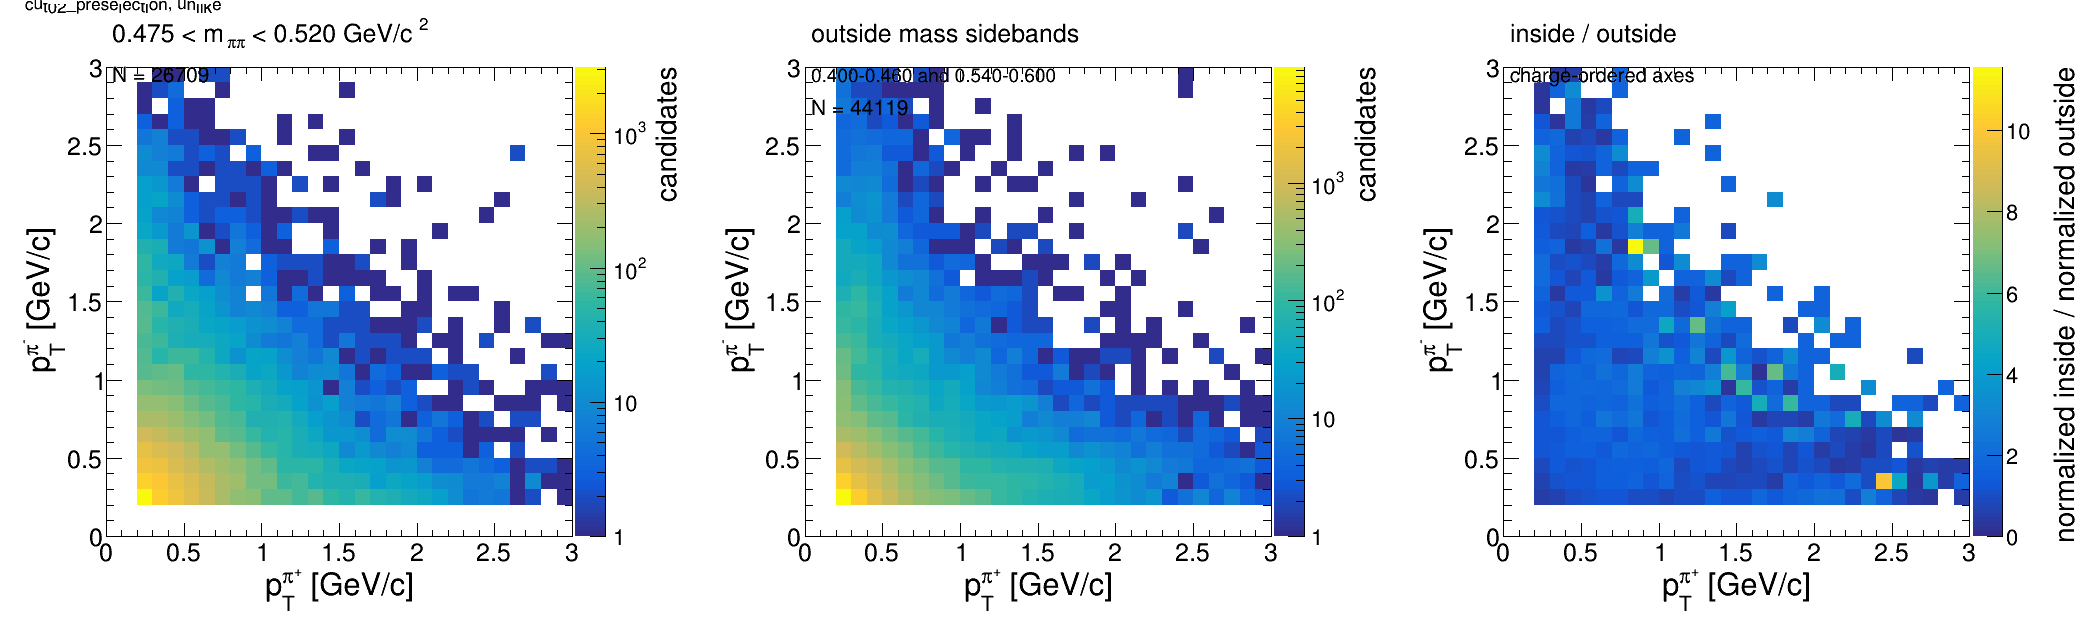

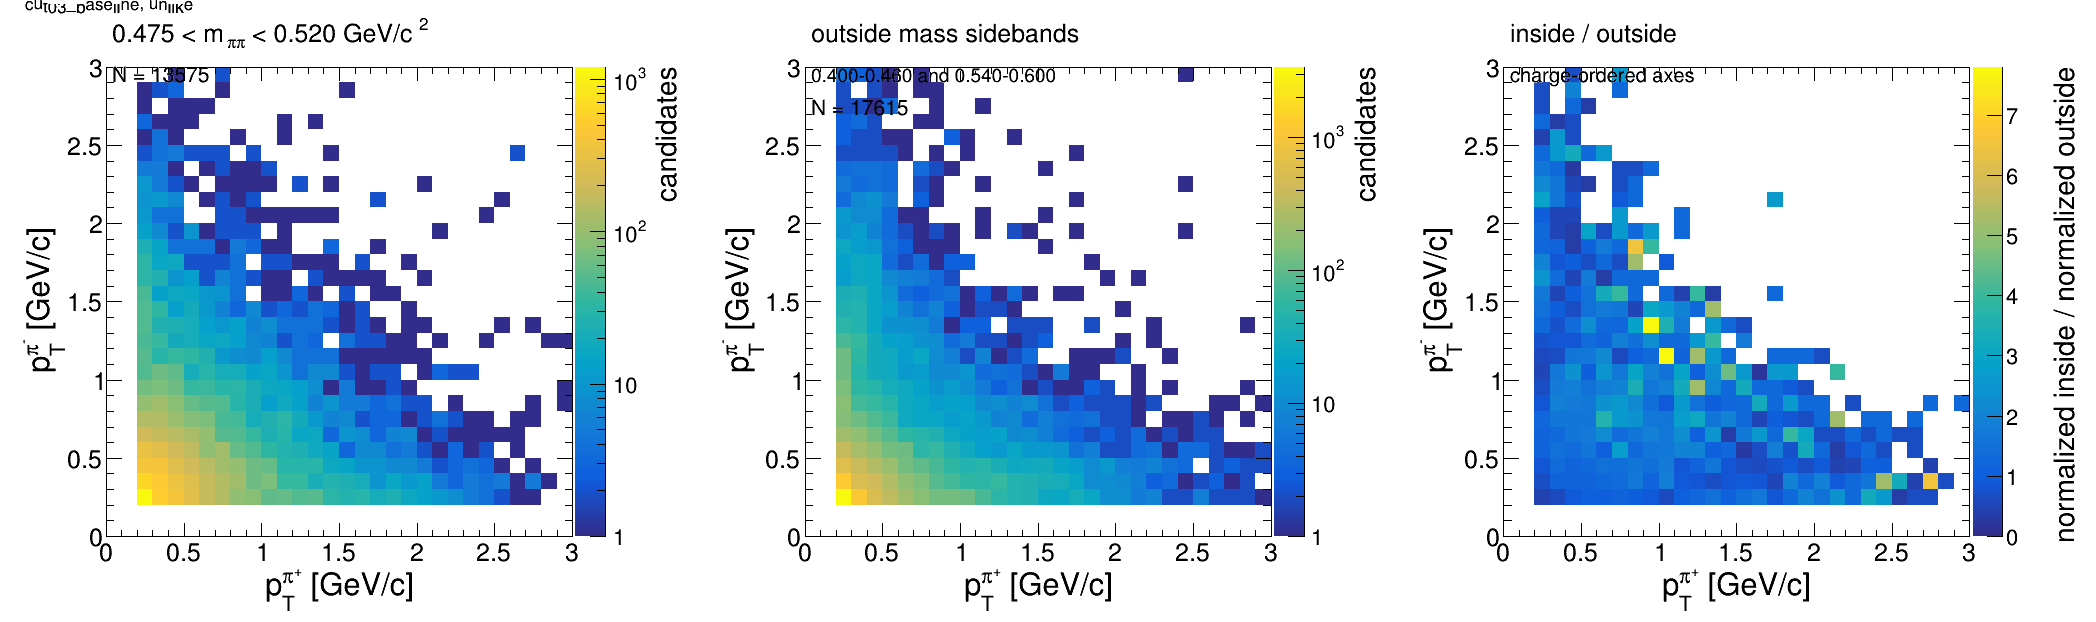

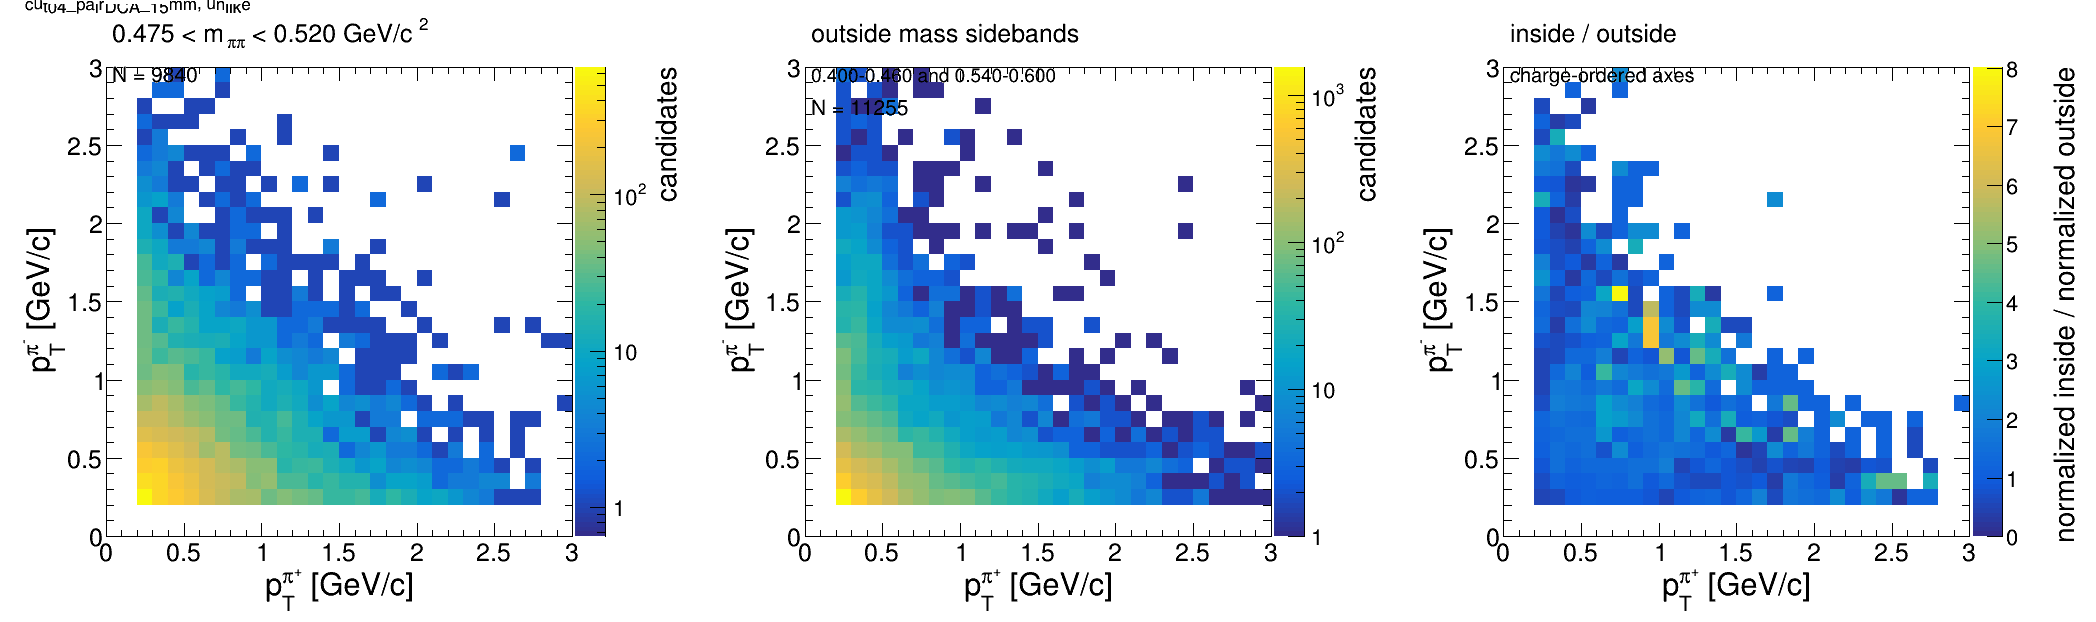

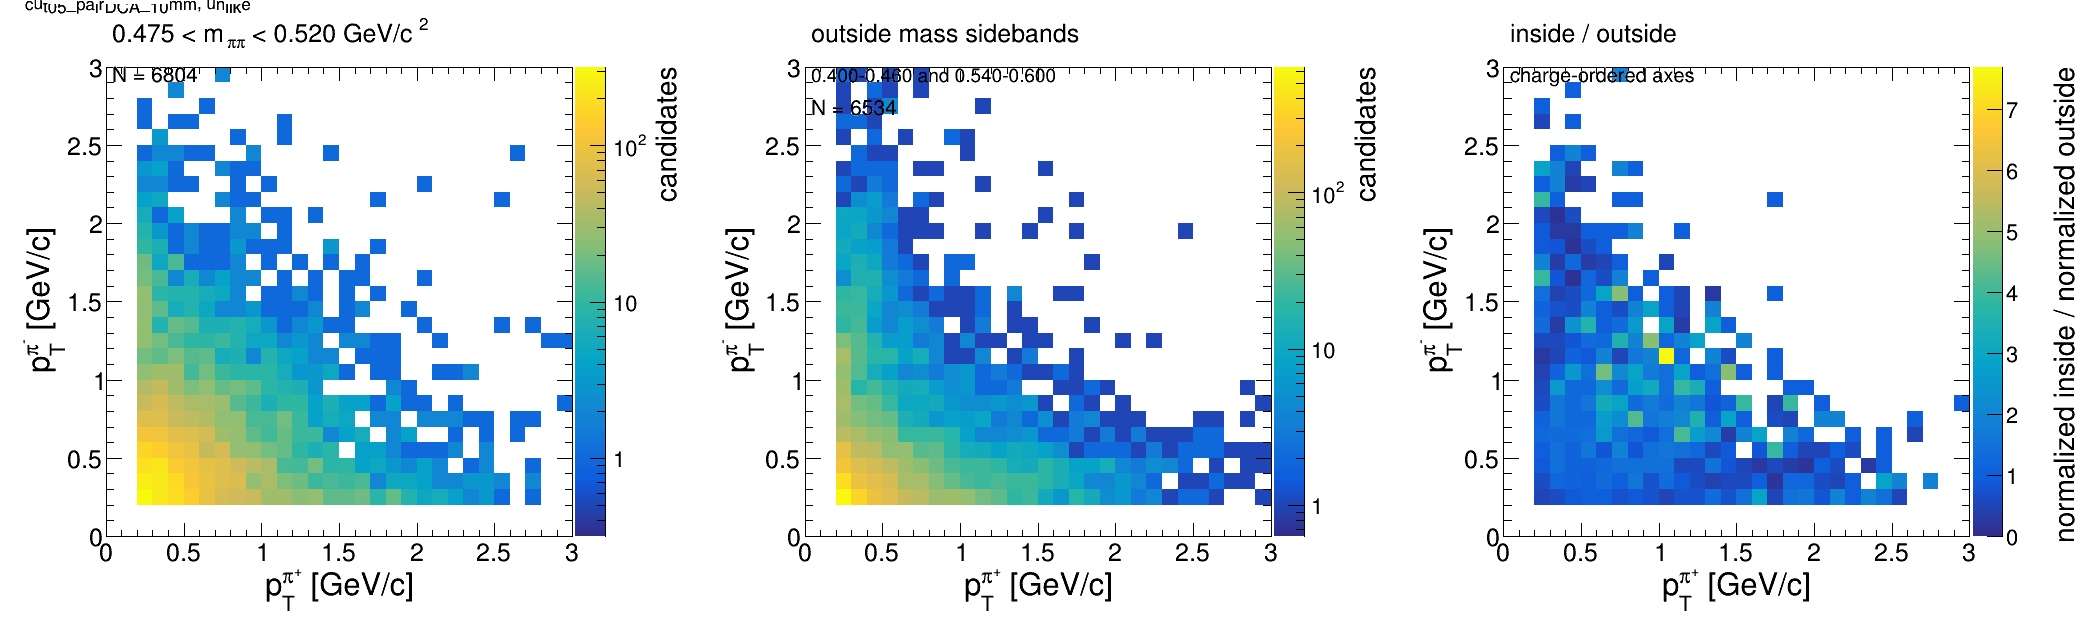

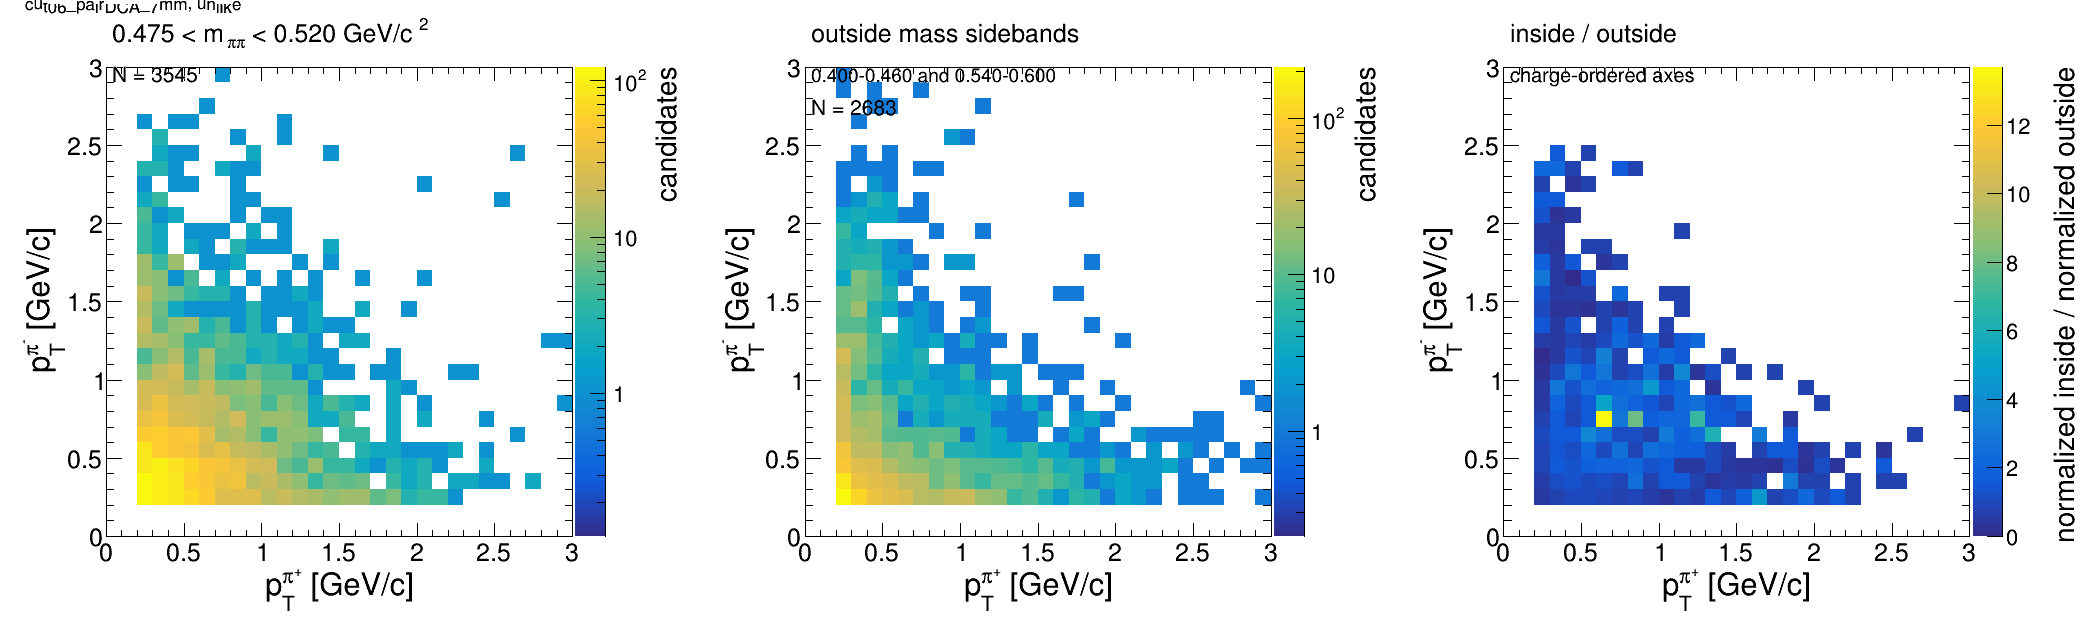

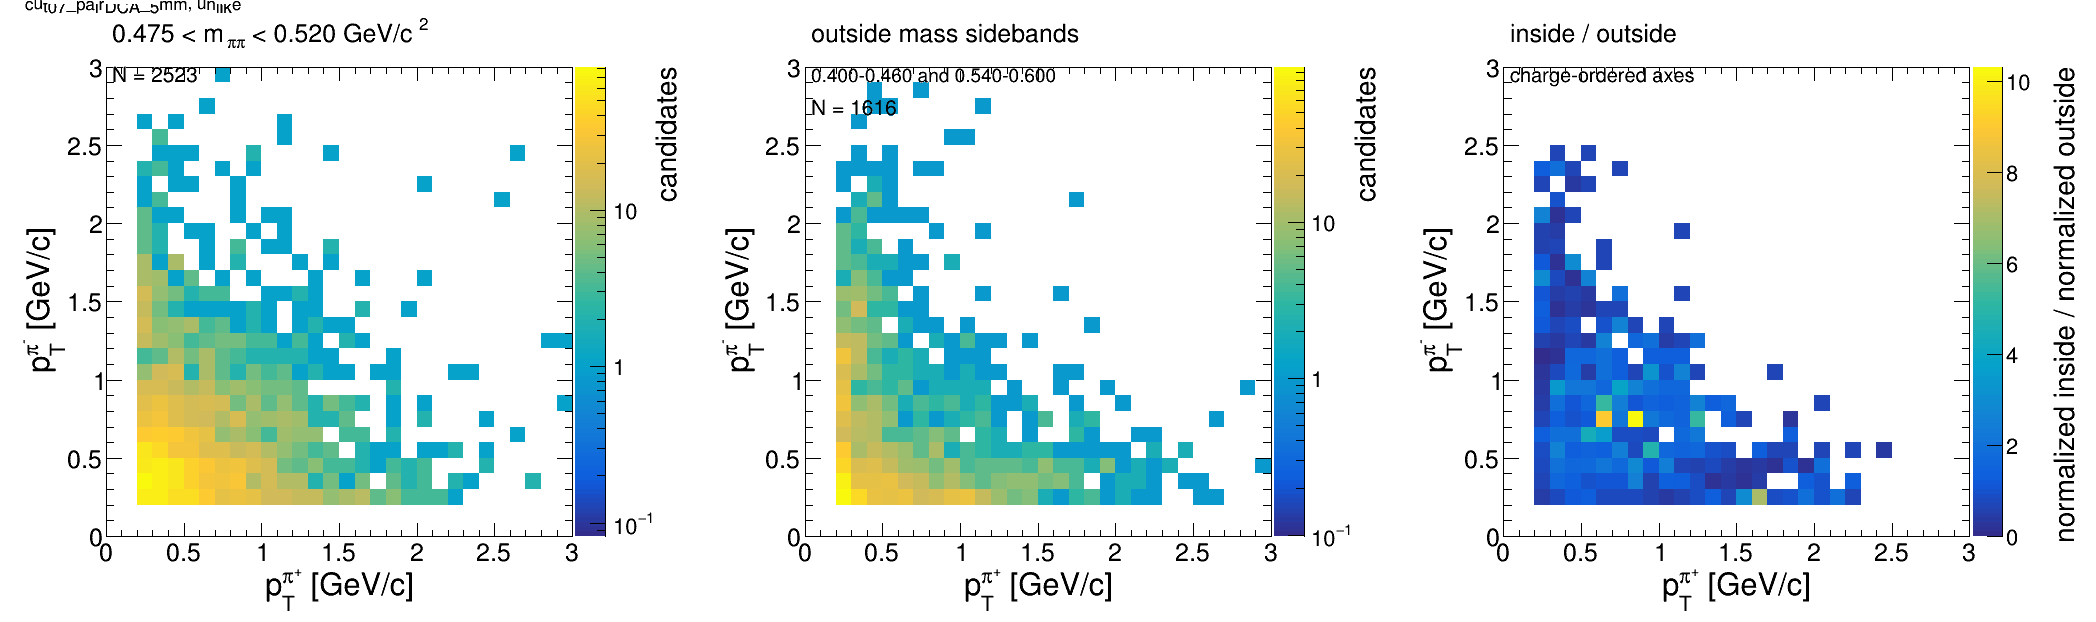

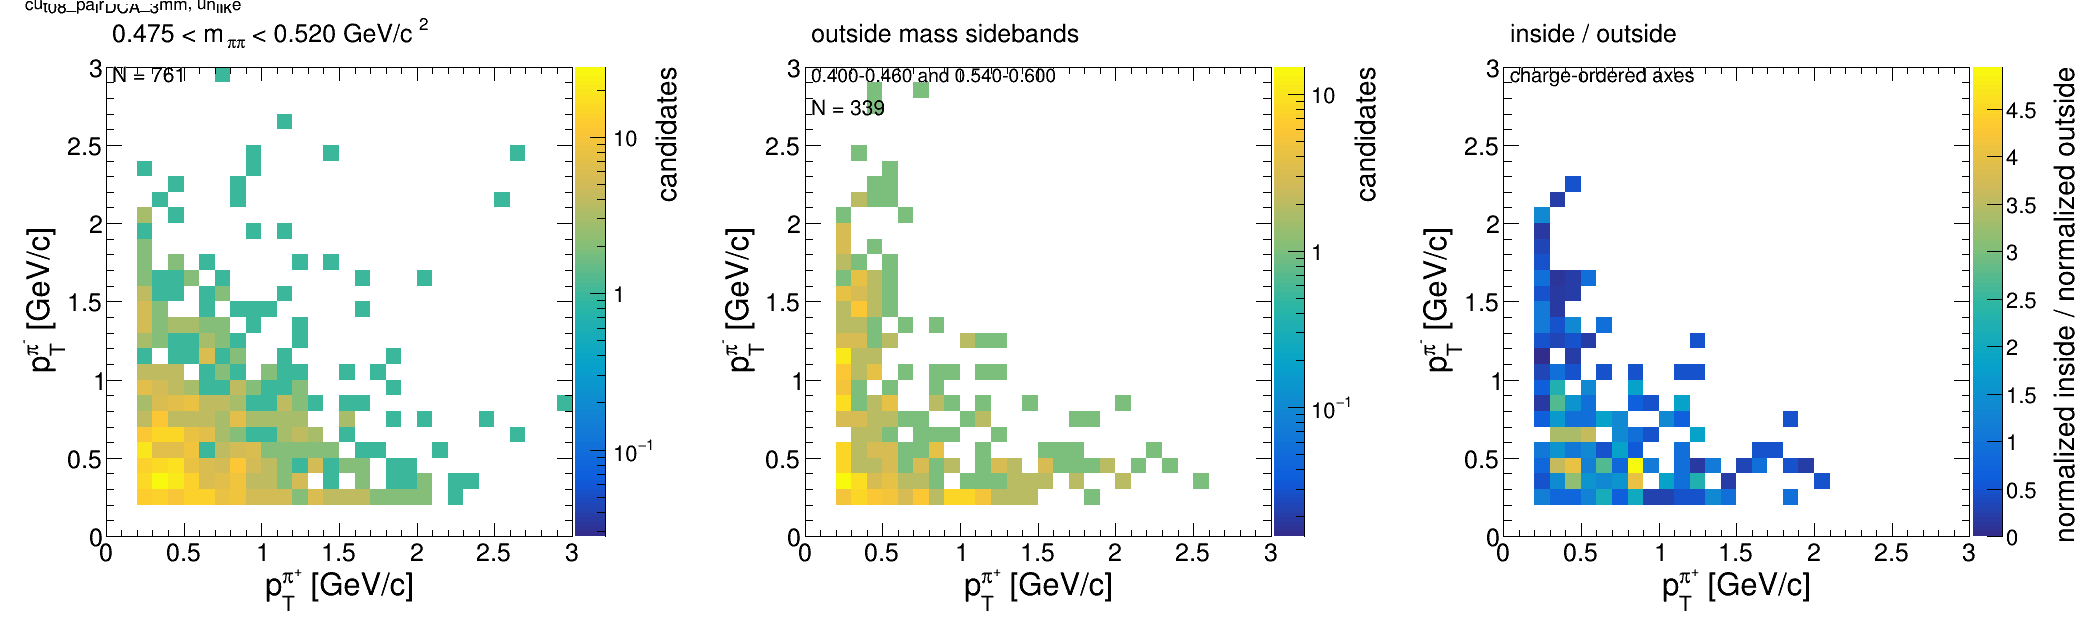

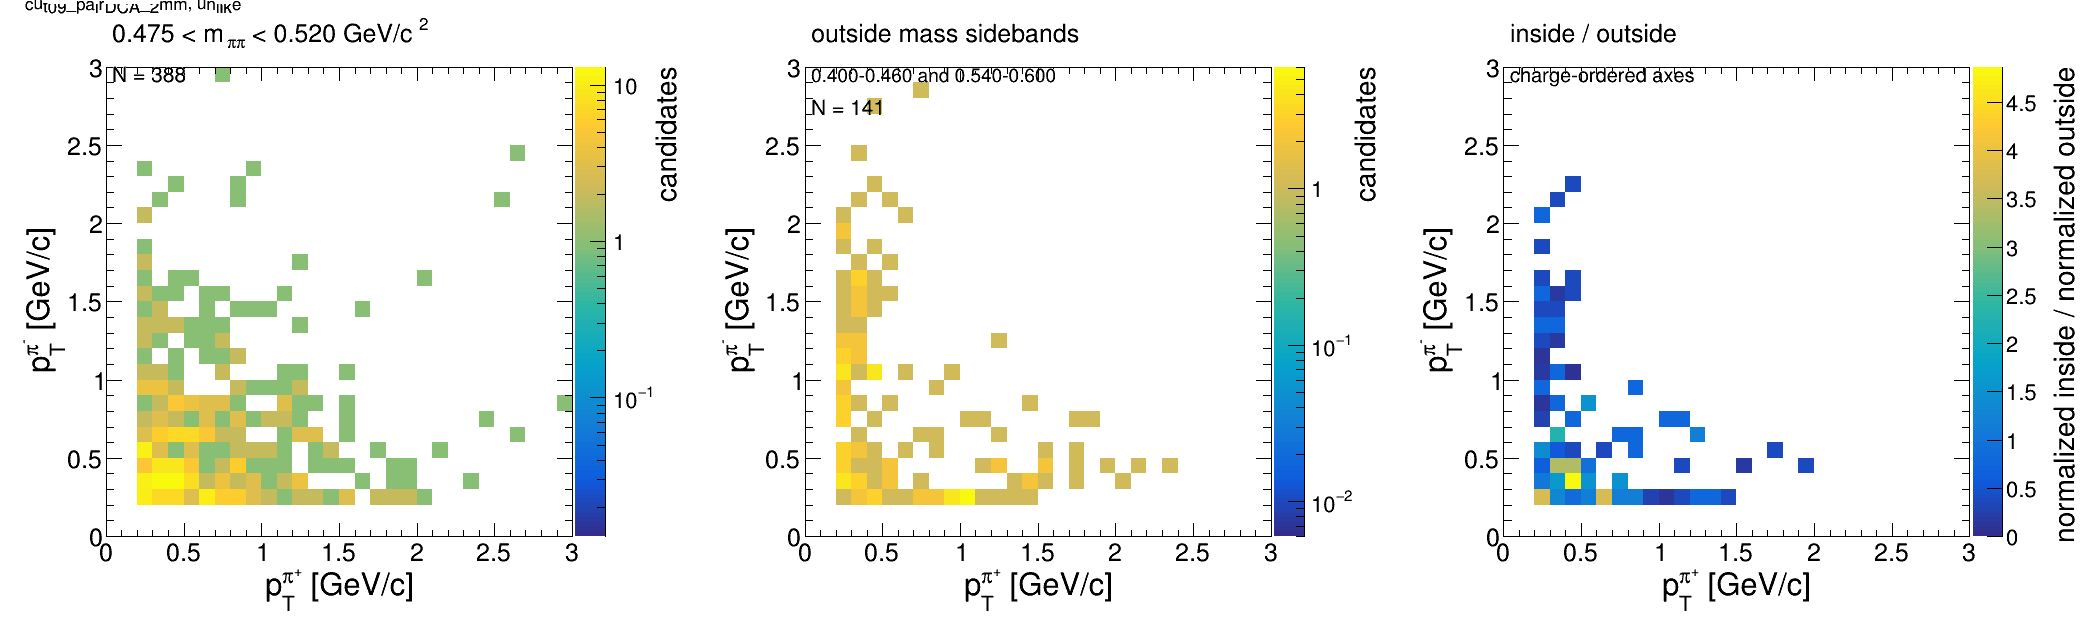

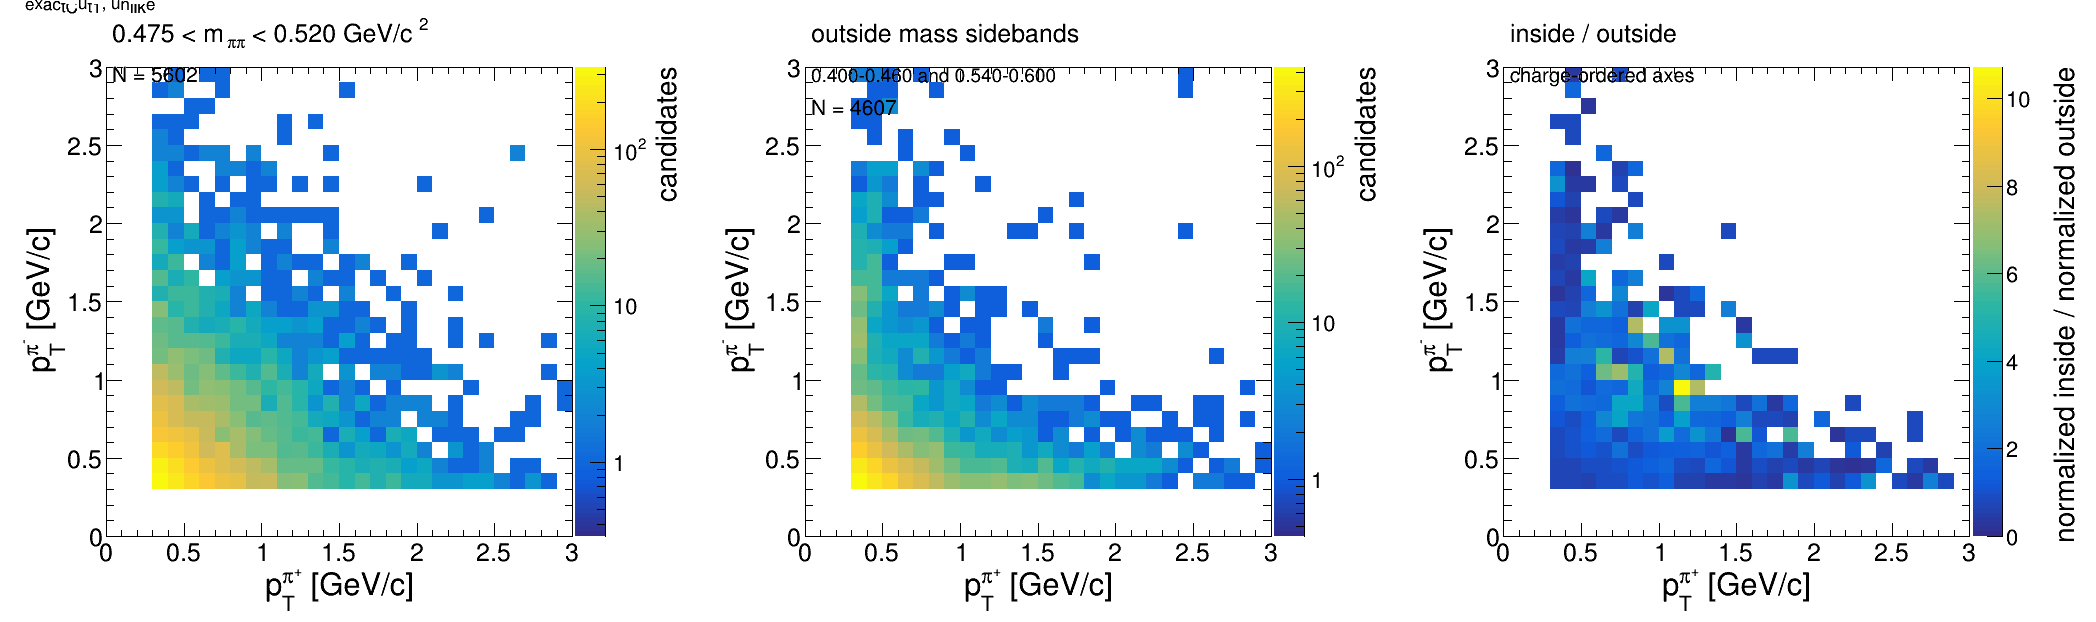

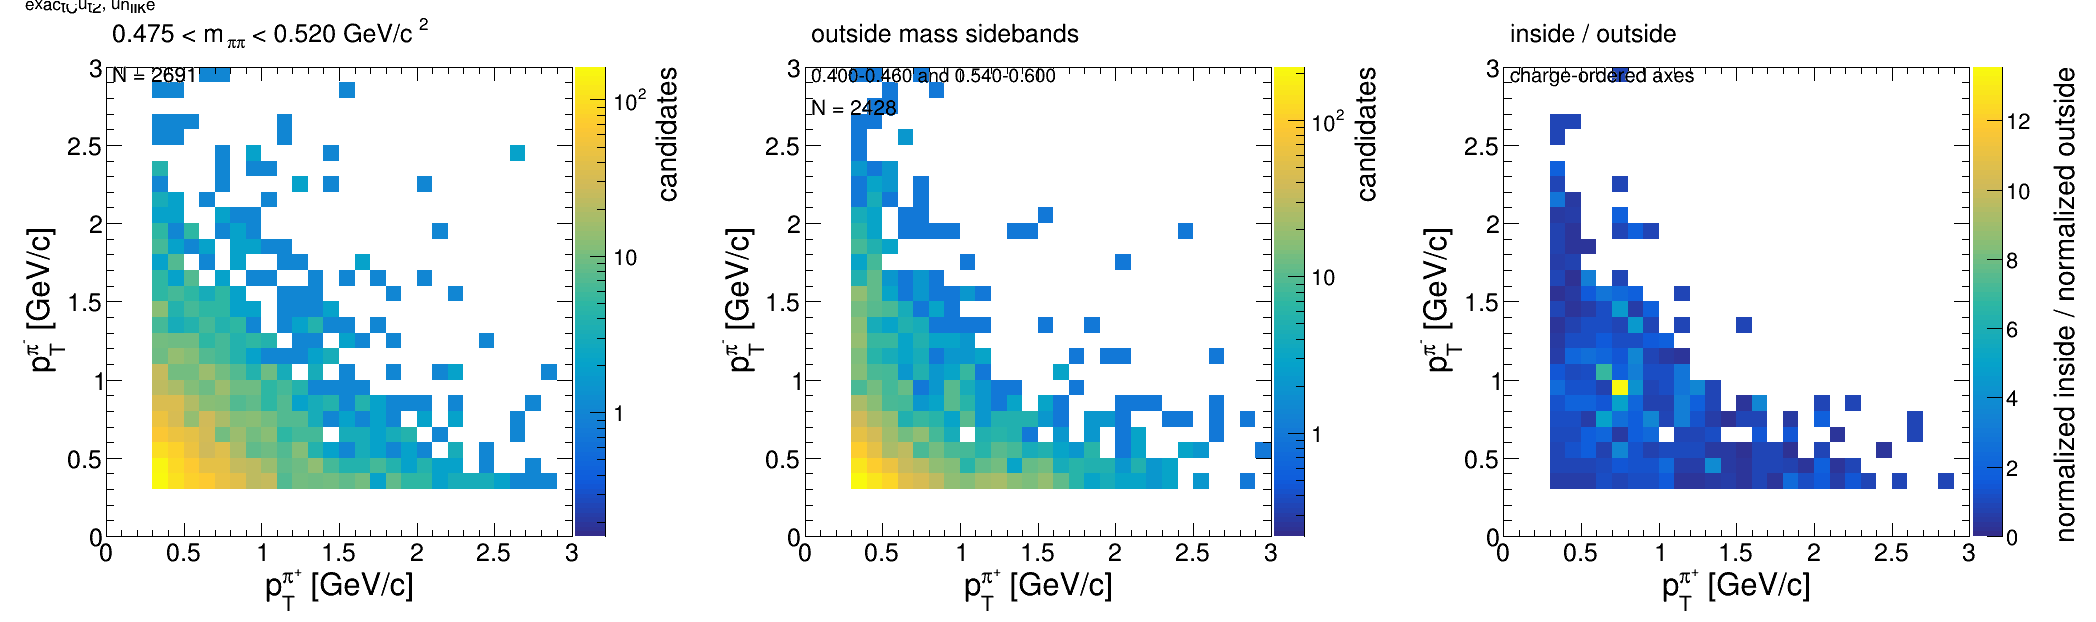

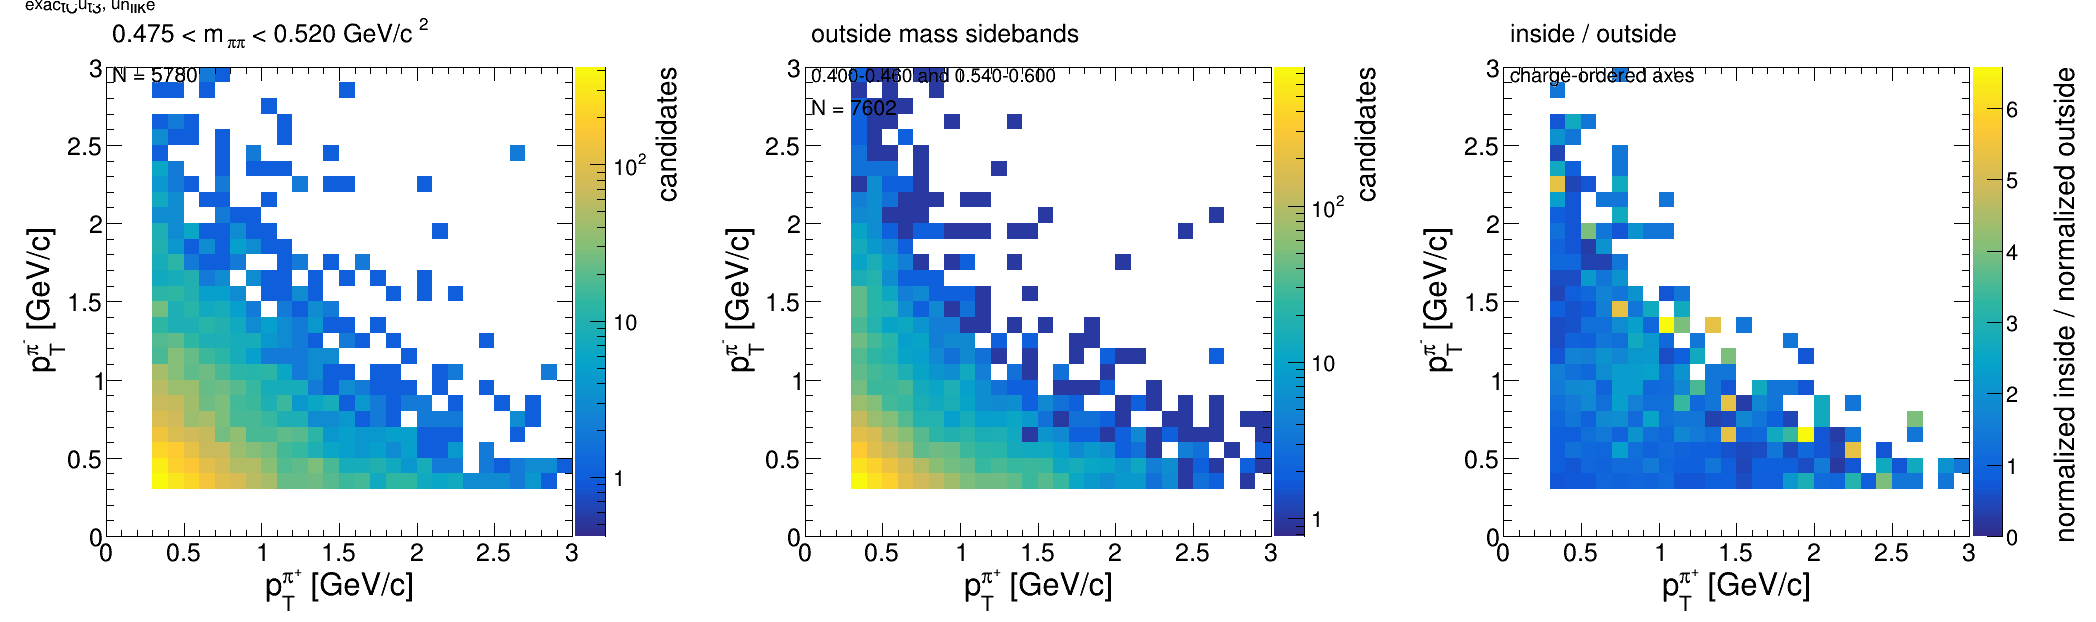

In [8]:
multipage_pdf = str(
    Path(output_dir) / "K0S_daughter_pt_QA_all_cuts.pdf"
)

all_canvases = []

for index, result in enumerate(cut_maps):
    cut_name = result["cut"]
    charge_ordered = result["charge_ordered"]

    if charge_ordered:
        x_title = "p_{T}^{#pi^{+}} [GeV/c]"
        y_title = "p_{T}^{#pi^{-}} [GeV/c]"
        axis_note = "charge-ordered axes"
    else:
        x_title = "p_{T,1}^{#pi} [GeV/c]"
        y_title = "p_{T,2}^{#pi} [GeV/c]"
        axis_note = "fallback: track-1/track-2 axes"

    canvas = keep(root.TCanvas(
        f"c_daughter_qa_{index}",
        f"c_daughter_qa_{index}",
        2100,
        650
    ))
    canvas.Divide(3, 1)

    # In mass window
    canvas.cd(1)
    set_pad_2d()
    root.gPad.SetLogz()

    h_inside = result["inside"]
    format_2d(
        h_inside,
        x_title,
        y_title,
        "candidates"
    )
    h_inside.Draw("COLZ")

    draw_panel_label(
        f"{mass_window[0]:.3f} < m_{{#pi#pi}} < {mass_window[1]:.3f} GeV/c^{{2}}"
    )
    draw_panel_label(
        f"N = {h_inside.Integral():.0f}",
        y=0.875,
        size=0.038
    )

    # Outside mass window
    canvas.cd(2)
    set_pad_2d()
    root.gPad.SetLogz()

    h_outside = result["outside"]
    format_2d(
        h_outside,
        x_title,
        y_title,
        "candidates"
    )
    h_outside.Draw("COLZ")

    sideband_text = (
        f"{outside_sidebands[0][0]:.3f}-{outside_sidebands[0][1]:.3f} "
        f"and {outside_sidebands[1][0]:.3f}-{outside_sidebands[1][1]:.3f}"
    )
    draw_panel_label("outside mass sidebands")
    draw_panel_label(sideband_text, y=0.875, size=0.034)
    draw_panel_label(
        f"N = {h_outside.Integral():.0f}",
        y=0.820,
        size=0.038
    )

    # Ratio
    canvas.cd(3)
    set_pad_2d()

    h_ratio = result["ratio"]
    ratio_z_title = (
        "normalized inside / normalized outside"
        if normalize_before_ratio
        else "inside / outside"
    )

    format_2d(
        h_ratio,
        x_title,
        y_title,
        ratio_z_title
    )
    h_ratio.Draw("COLZ")

    draw_panel_label("inside / outside")
    draw_panel_label(axis_note, y=0.875, size=0.035)

    canvas.cd()
    title = keep(root.TLatex())
    title.SetNDC()
    title.SetTextFont(42)
    title.SetTextSize(0.030)
    title.DrawLatex(
        0.012,
        0.985,
        f"{cut_name}, {charge_name}"
    )

    canvas.Update()
    canvas.Draw()
    all_canvases.append(canvas)

    safe_cut = cut_name.replace("/", "_")

    if save_individual_pdf:
        canvas.SaveAs(
            str(Path(output_dir) / f"K0S_daughter_pt_{safe_cut}.pdf")
        )

    if save_png:
        canvas.SaveAs(
            str(Path(output_dir) / f"K0S_daughter_pt_{safe_cut}.png")
        )

    if save_multipage_pdf:
        if index == 0:
            canvas.Print(multipage_pdf + "(")
        elif index == len(cut_maps) - 1:
            canvas.Print(multipage_pdf + ")")
        else:
            canvas.Print(multipage_pdf)

print("Finished per-cut daughter QA")

## Summary canvas for all cuts

The following optional section draws only the normalized inside/outside ratio for
all cuts on one multi-pad canvas. This is useful for quickly checking how the
daughter-phase-space bias evolves as the cuts become tighter.

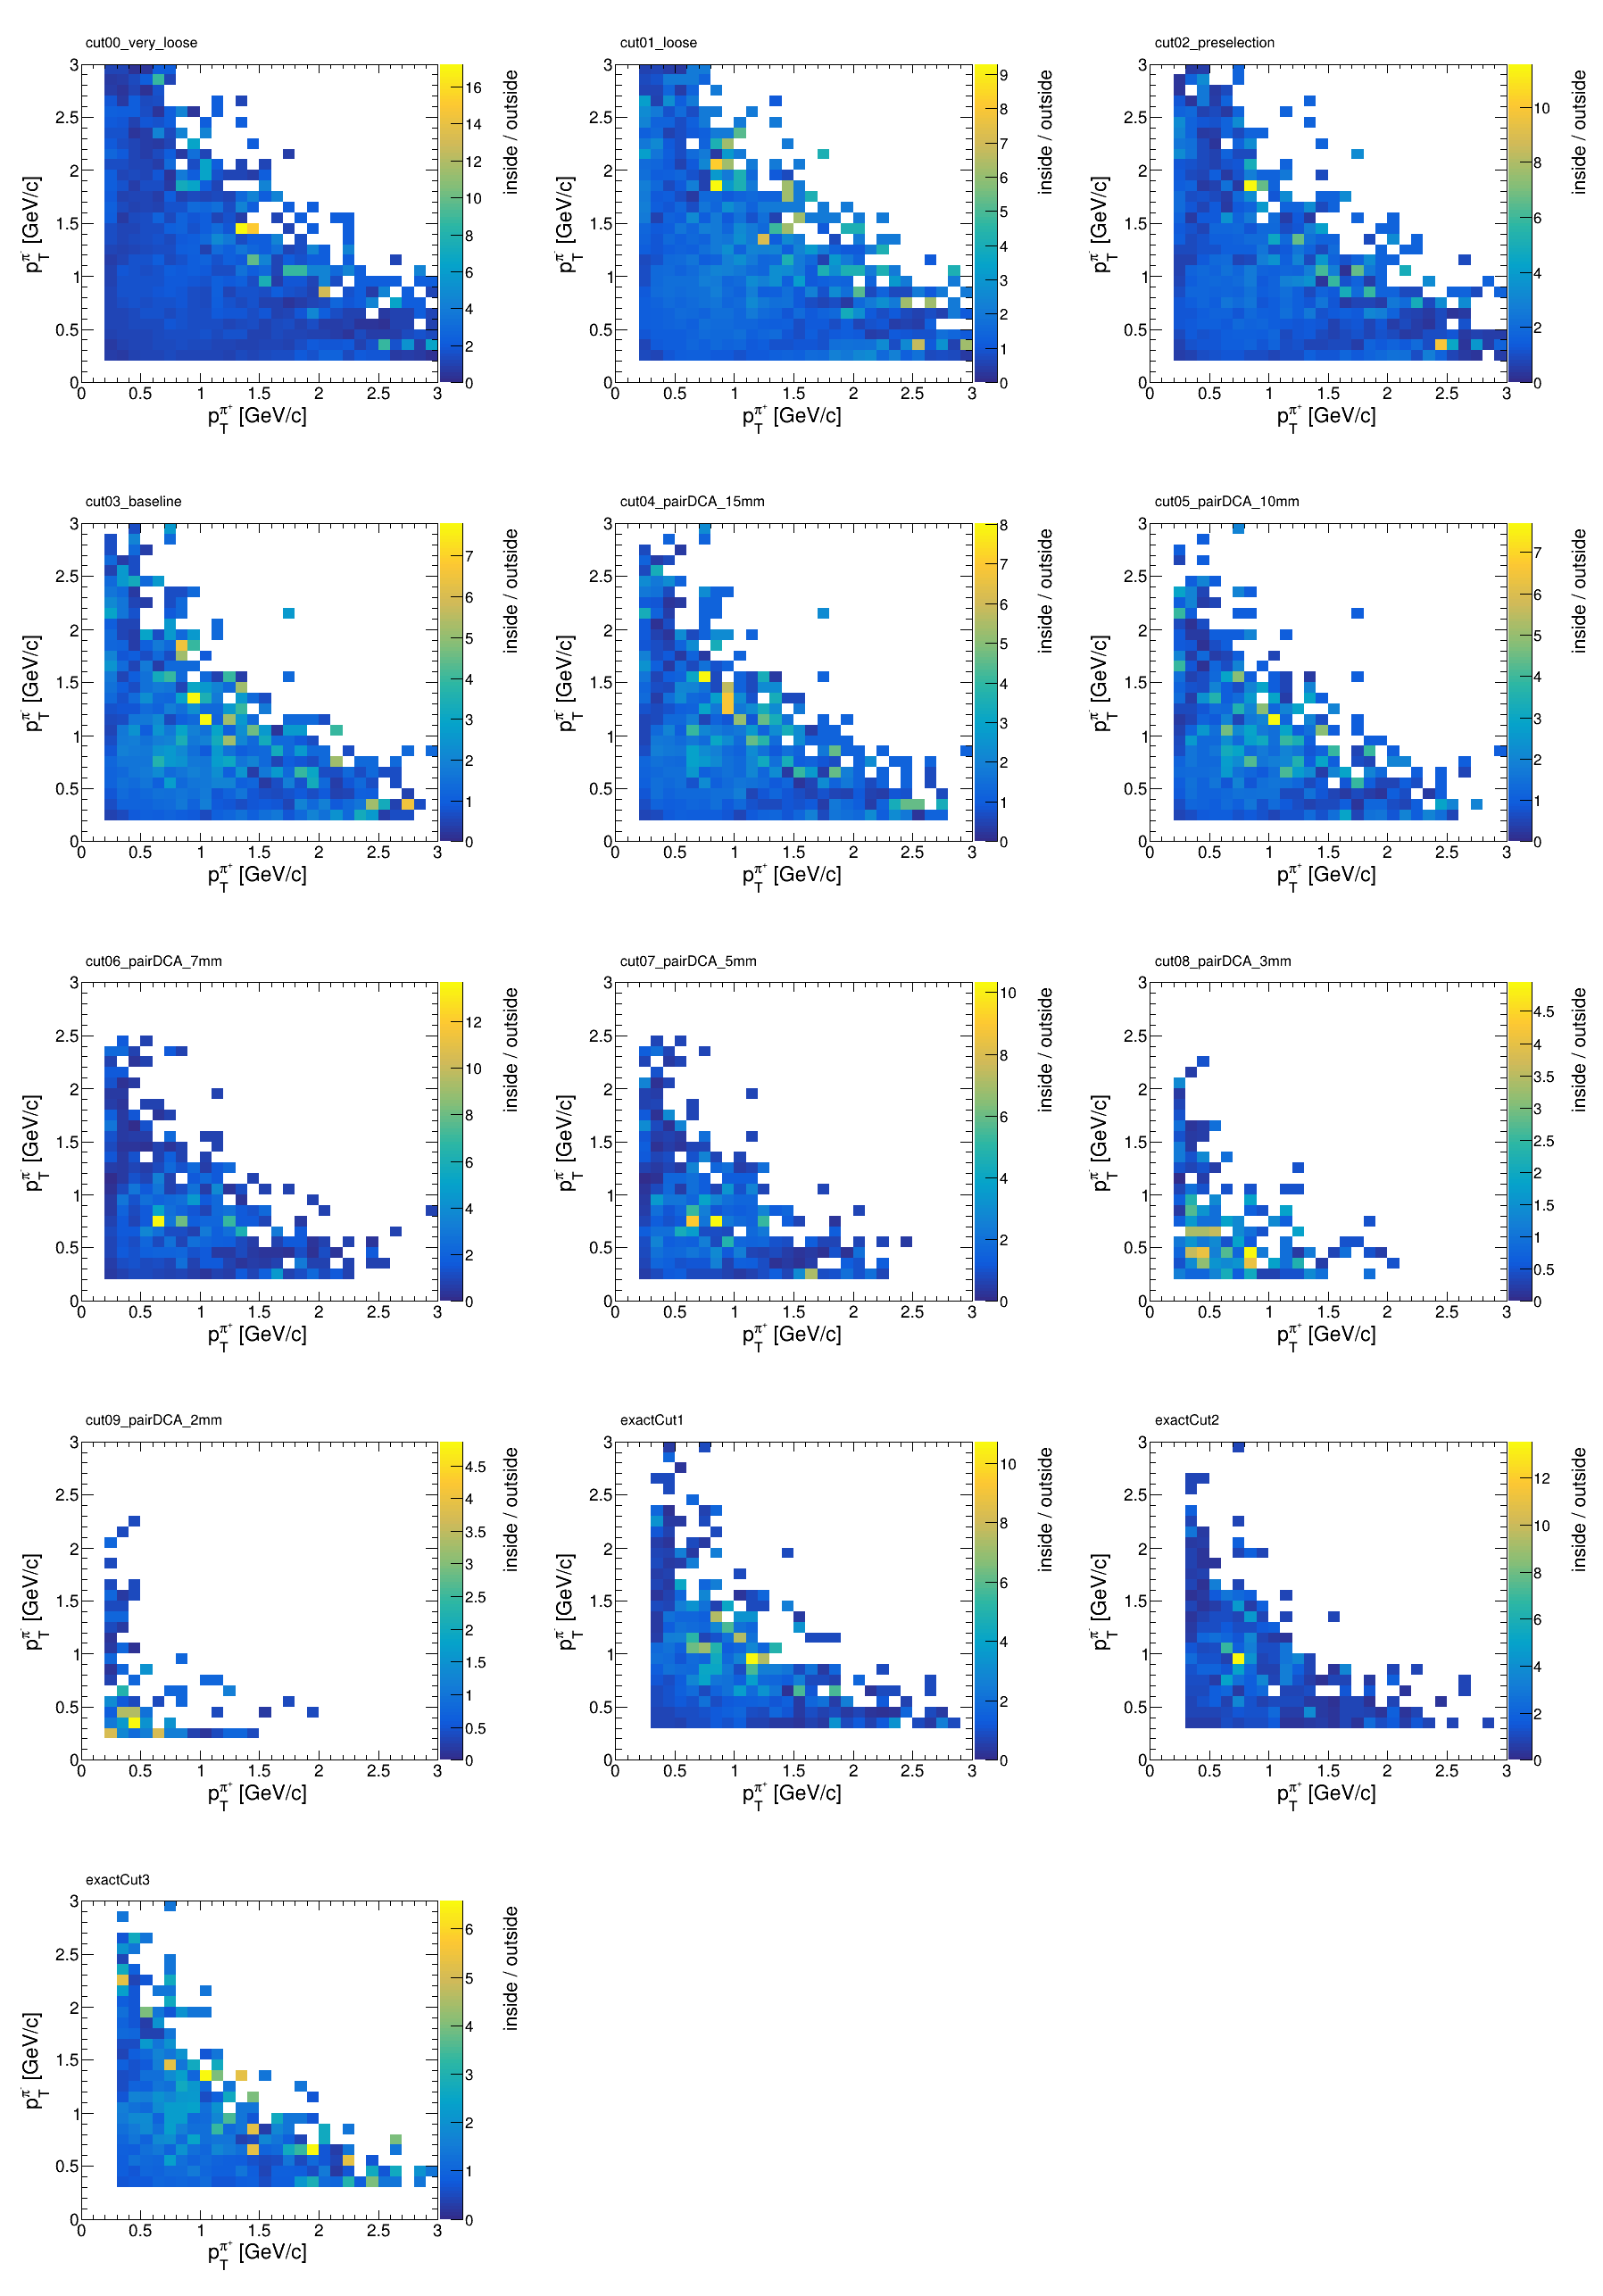

In [9]:
if len(cut_maps) > 0:
    ncols = 3
    nrows = math.ceil(len(cut_maps) / ncols)

    c_ratio_summary = keep(root.TCanvas(
        "c_ratio_summary",
        "c_ratio_summary",
        1800,
        520 * nrows
    ))
    c_ratio_summary.Divide(ncols, nrows)

    for index, result in enumerate(cut_maps):
        c_ratio_summary.cd(index + 1)
        set_pad_2d()

        h_ratio = result["ratio"]

        if result["charge_ordered"]:
            x_title = "p_{T}^{#pi^{+}} [GeV/c]"
            y_title = "p_{T}^{#pi^{-}} [GeV/c]"
        else:
            x_title = "p_{T,1}^{#pi} [GeV/c]"
            y_title = "p_{T,2}^{#pi} [GeV/c]"

        format_2d(
            h_ratio,
            x_title,
            y_title,
            "inside / outside"
        )

        h_ratio.Draw("COLZ")
        draw_panel_label(result["cut"], size=0.038)

    c_ratio_summary.Draw()

    if save_individual_pdf:
        c_ratio_summary.SaveAs(
            str(Path(output_dir) / "K0S_daughter_pt_ratio_all_cuts.pdf")
        )

In [10]:
print("Input histogram paths used:")

for result in cut_maps:
    print(
        f"{result['cut']:28s}",
        result["source_path"],
        "(charge ordered)" if result["charge_ordered"] else "(track 1 / track 2)"
    )

print("Plots saved to:", output_dir)

Input histogram paths used:
cut00_very_loose             cut00_very_loose/unlike/h3_Kshort_ptplus_vs_ptminus_vs_mass (charge ordered)
cut01_loose                  cut01_loose/unlike/h3_Kshort_ptplus_vs_ptminus_vs_mass (charge ordered)
cut02_preselection           cut02_preselection/unlike/h3_Kshort_ptplus_vs_ptminus_vs_mass (charge ordered)
cut03_baseline               cut03_baseline/unlike/h3_Kshort_ptplus_vs_ptminus_vs_mass (charge ordered)
cut04_pairDCA_15mm           cut04_pairDCA_15mm/unlike/h3_Kshort_ptplus_vs_ptminus_vs_mass (charge ordered)
cut05_pairDCA_10mm           cut05_pairDCA_10mm/unlike/h3_Kshort_ptplus_vs_ptminus_vs_mass (charge ordered)
cut06_pairDCA_7mm            cut06_pairDCA_7mm/unlike/h3_Kshort_ptplus_vs_ptminus_vs_mass (charge ordered)
cut07_pairDCA_5mm            cut07_pairDCA_5mm/unlike/h3_Kshort_ptplus_vs_ptminus_vs_mass (charge ordered)
cut08_pairDCA_3mm            cut08_pairDCA_3mm/unlike/h3_Kshort_ptplus_vs_ptminus_vs_mass (charge ordered)
cut09_pairDCA_2m

## Daughter momentum-sharing variables

For each cut, this section compares the signal-window and sideband distributions of:

\[
f_{+} = \frac{p_T^{+}}{p_T^{+}+p_T^{-}},
\qquad
f_{-} = \frac{p_T^{-}}{p_T^{+}+p_T^{-}},
\qquad
R_{+-} = \frac{p_T^{+}}{p_T^{-}}.
\]

The first two variables are bounded between 0 and 1 and satisfy \(f_{+}+f_{-}=1\).
They are usually more stable and easier to compare than \(p_T^{+}/p_T^{-}\), which
has a long tail when \(p_T^{-}\) is small.

In [11]:
# Momentum-sharing histogram configuration
fraction_bins = 50
fraction_range = (0.0, 1.0)

pt_ratio_bins = 80
pt_ratio_range = (0.0, 4.0)

normalize_fraction_histograms = True

In [ ]:
def normalize_histogram(hist):
    integral = hist.Integral()

    if integral > 0.0:
        hist.Scale(1.0 / integral)


def divide_histograms(numerator, denominator, name):
    ratio = numerator.Clone(name)
    ratio.SetDirectory(0)
    ratio.Reset("ICES")
    keep(ratio)

    for ibin in range(1, ratio.GetNbinsX() + 1):
        a = numerator.GetBinContent(ibin)
        ea = numerator.GetBinError(ibin)

        b = denominator.GetBinContent(ibin)
        eb = denominator.GetBinError(ibin)

        if b <= 0.0:
            ratio.SetBinContent(ibin, 0.0)
            ratio.SetBinError(ibin, 0.0)
            continue

        value = a / b

        relative_error2 = 0.0

        if a > 0.0:
            relative_error2 += (ea / a) ** 2

        if b > 0.0:
            relative_error2 += (eb / b) ** 2

        error = (
            abs(value) * math.sqrt(relative_error2)
            if relative_error2 > 0.0
            else 0.0
        )

        ratio.SetBinContent(ibin, value)
        ratio.SetBinError(ibin, error)

    return ratio


def make_daughter_pt_projections(h2, prefix):
    # X axis is pT+.
    # Integrate over the complete pT- axis.
    h_ptplus = h2.ProjectionX(
        f"{prefix}_ptplus",
        1,
        h2.GetNbinsY(),
        "e"
    )
    h_ptplus.SetDirectory(0)
    keep(h_ptplus)

    # Y axis is pT-.
    # Integrate over the complete pT+ axis.
    h_ptminus = h2.ProjectionY(
        f"{prefix}_ptminus",
        1,
        h2.GetNbinsX(),
        "e"
    )
    h_ptminus.SetDirectory(0)
    keep(h_ptminus)

    # Make independent working copies.
    h_ptplus_work = h_ptplus.Clone(f"{prefix}_ptplus_work")
    h_ptminus_work = h_ptminus.Clone(f"{prefix}_ptminus_work")

    h_ptplus_work.SetDirectory(0)
    h_ptminus_work.SetDirectory(0)

    keep(h_ptplus_work)
    keep(h_ptminus_work)

    # Optional shape normalization.
    if normalize_fraction_histograms:
        normalize_histogram(h_ptplus_work)
        normalize_histogram(h_ptminus_work)

    # Direct positive/negative ratio.
    h_plus_over_minus = divide_histograms(
        h_ptplus_work,
        h_ptminus_work,
        f"{prefix}_plus_over_minus"
    )

    # Common average:
    # h_avg = 0.5 * (h_plus + h_minus)
    h_average = h_ptplus_work.Clone(f"{prefix}_average")
    h_average.SetDirectory(0)
    keep(h_average)

    h_average.Add(h_ptminus_work)
    h_average.Scale(0.5)

    # Each charge divided by the common average.
    h_plus_over_average = divide_histograms(
        h_ptplus_work,
        h_average,
        f"{prefix}_plus_over_average"
    )

    h_minus_over_average = divide_histograms(
        h_ptminus_work,
        h_average,
        f"{prefix}_minus_over_average"
    )

    return {
        "ptplus": h_ptplus_work,
        "ptminus": h_ptminus_work,
        "average": h_average,
        "plus_over_minus": h_plus_over_minus,
        "plus_over_average": h_plus_over_average,
        "minus_over_average": h_minus_over_average,
    }

Prepared momentum-sharing histograms for 13 cuts


In [13]:
def format_1d(hist, x_title, y_title):
    hist.SetTitle("")
    hist.GetXaxis().SetTitle(x_title)
    hist.GetYaxis().SetTitle(y_title)

    hist.GetXaxis().SetTitleSize(0.055)
    hist.GetYaxis().SetTitleSize(0.055)
    hist.GetXaxis().SetLabelSize(0.045)
    hist.GetYaxis().SetLabelSize(0.045)

    hist.GetXaxis().SetTitleOffset(1.00)
    hist.GetYaxis().SetTitleOffset(1.10)

    hist.GetXaxis().CenterTitle()


def set_pad_1d():
    root.gPad.SetLeftMargin(0.13)
    root.gPad.SetBottomMargin(0.13)
    root.gPad.SetRightMargin(0.05)
    root.gPad.SetTopMargin(0.10)
    root.gPad.SetTicks(1, 1)


def draw_inside_outside(inside, outside, x_title, title_text):
    inside.SetLineColor(root.kBlue + 1)
    inside.SetMarkerColor(root.kBlue + 1)
    inside.SetLineWidth(3)

    outside.SetLineColor(root.kRed + 1)
    outside.SetMarkerColor(root.kRed + 1)
    outside.SetLineWidth(3)

    ymax = max(inside.GetMaximum(), outside.GetMaximum())
    inside.SetMaximum(1.20 * ymax if ymax > 0.0 else 1.0)
    inside.SetMinimum(0.0)

    y_title = "normalized candidates" if normalize_fraction_histograms else "candidates"

    format_1d(inside, x_title, y_title)
    format_1d(outside, x_title, y_title)

    inside.Draw("HIST")
    outside.Draw("HIST SAME")

    legend = keep(root.TLegend(0.58, 0.72, 0.90, 0.88))
    legend.SetBorderSize(0)
    legend.SetFillStyle(0)
    legend.SetTextSize(0.038)
    legend.AddEntry(inside, "K^{0}_{S} mass window", "l")
    legend.AddEntry(outside, "outside sidebands", "l")
    legend.Draw()

    draw_panel_label(title_text, x=0.15, y=0.94, size=0.043)

Finished momentum-sharing QA


Info in <TCanvas::Print>: pdf file output/K0S_daughter_QA/K0S_daughter_momentum_sharing_all_cuts.pdf has been created using the current canvas
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_momentum_sharing_all_cuts.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_momentum_sharing_all_cuts.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_momentum_sharing_all_cuts.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_momentum_sharing_all_cuts.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_momentum_sharing_all_cuts.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_momentum_sharing_all_cuts.pdf
Info in <TCanvas::Print>: Current canvas added to pdf file output/K0S_daughter_QA/K0S_daughter_momentum_sha

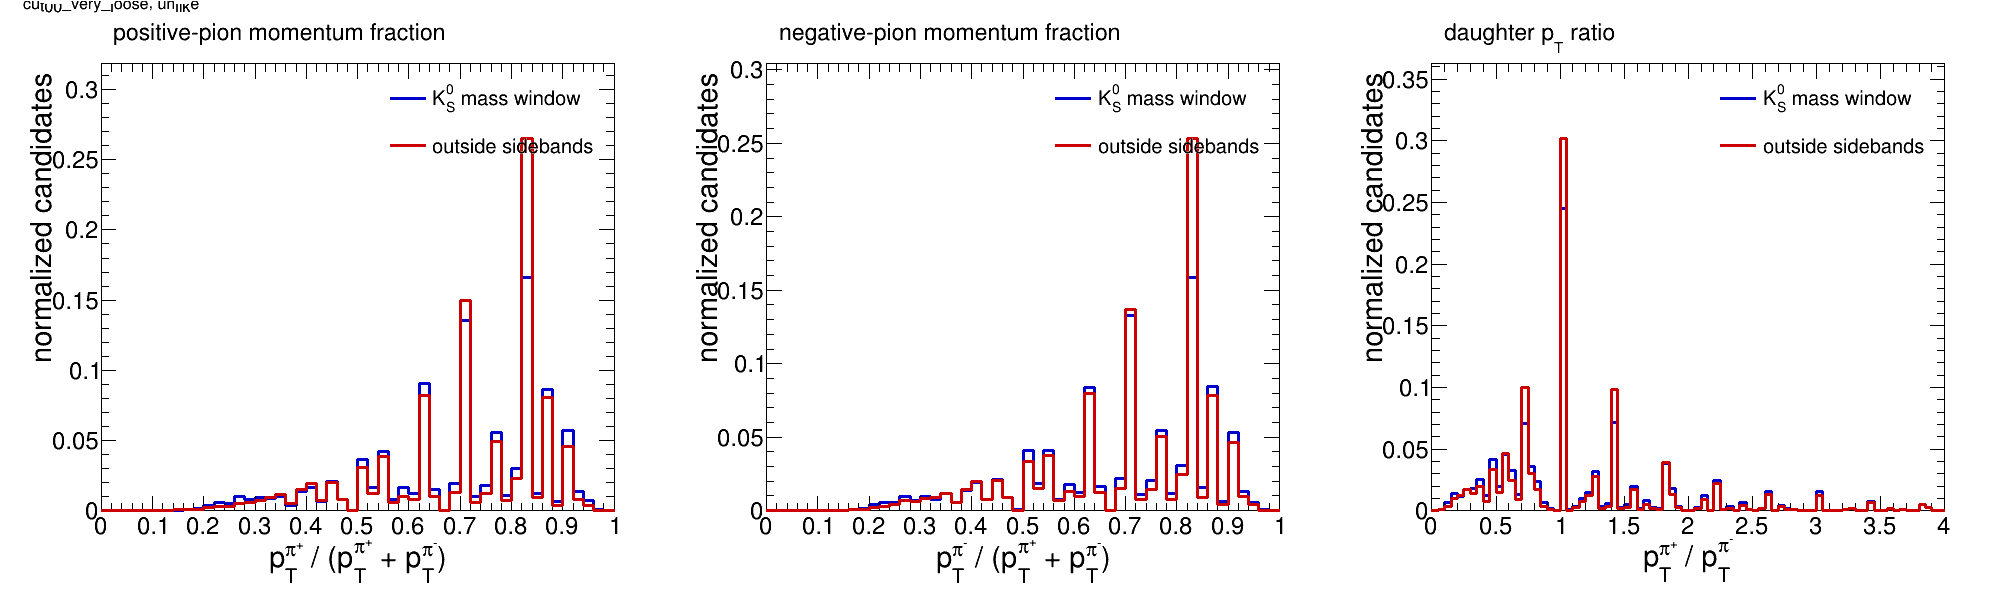

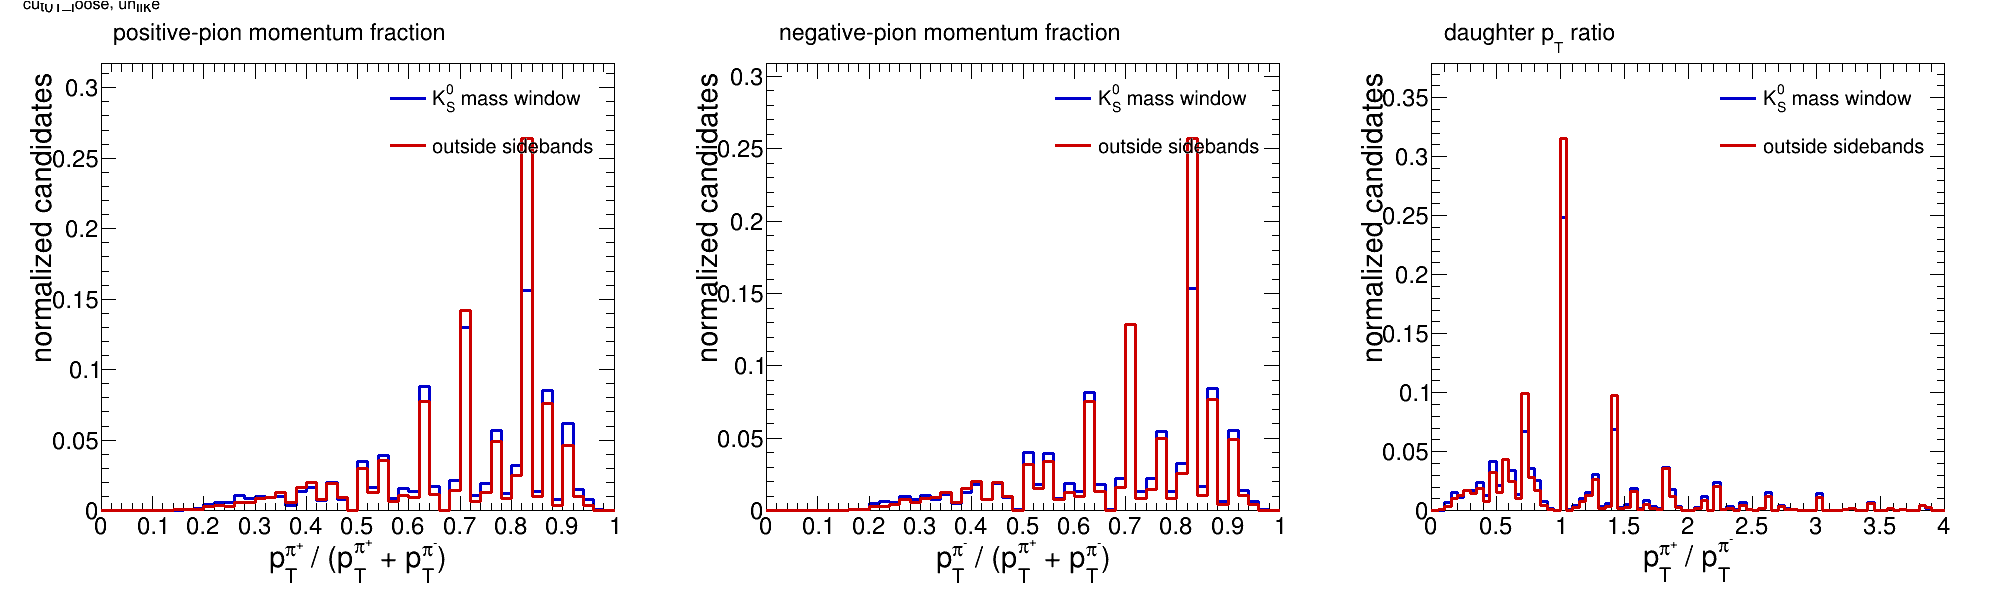

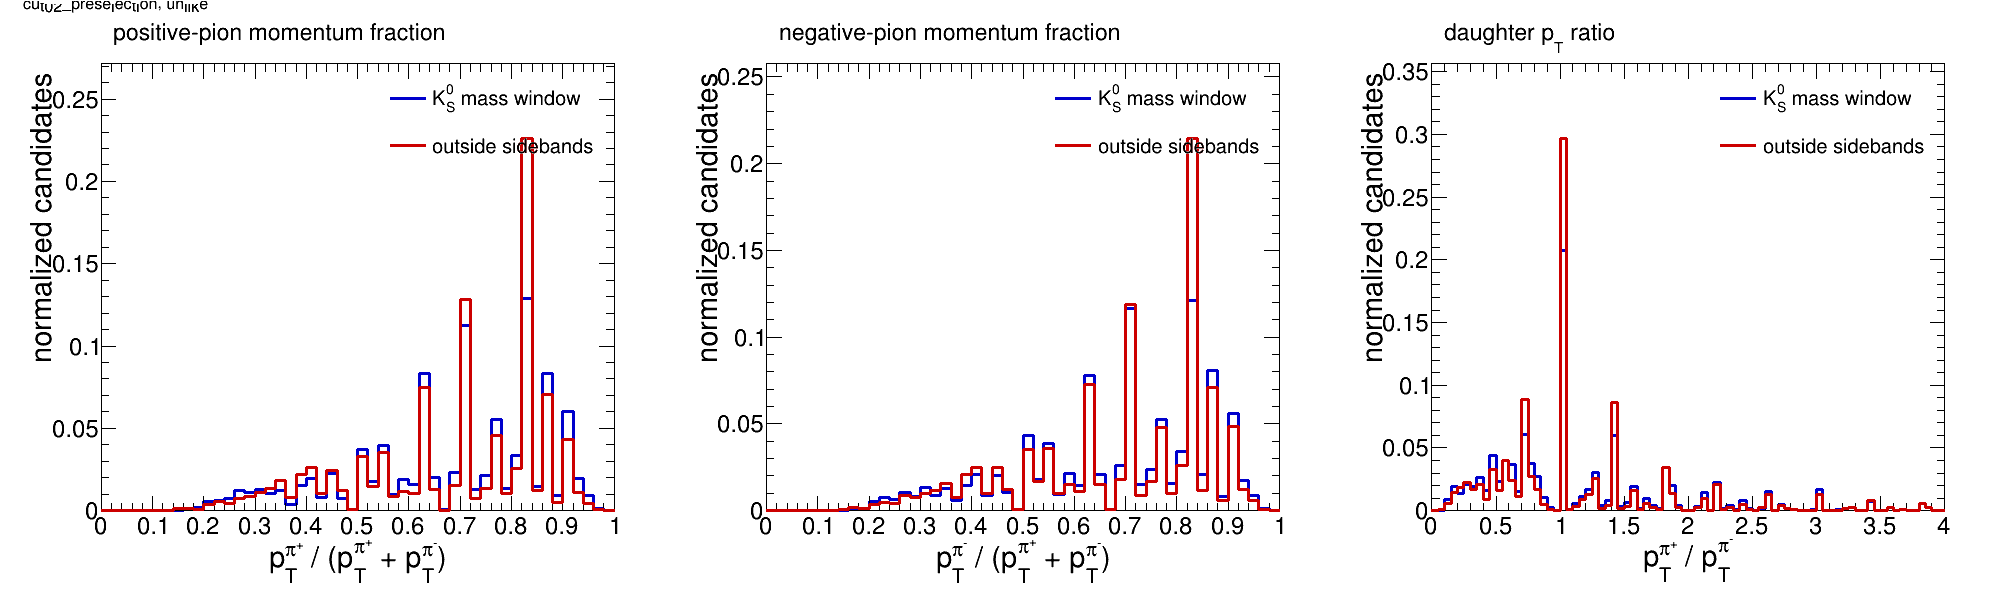

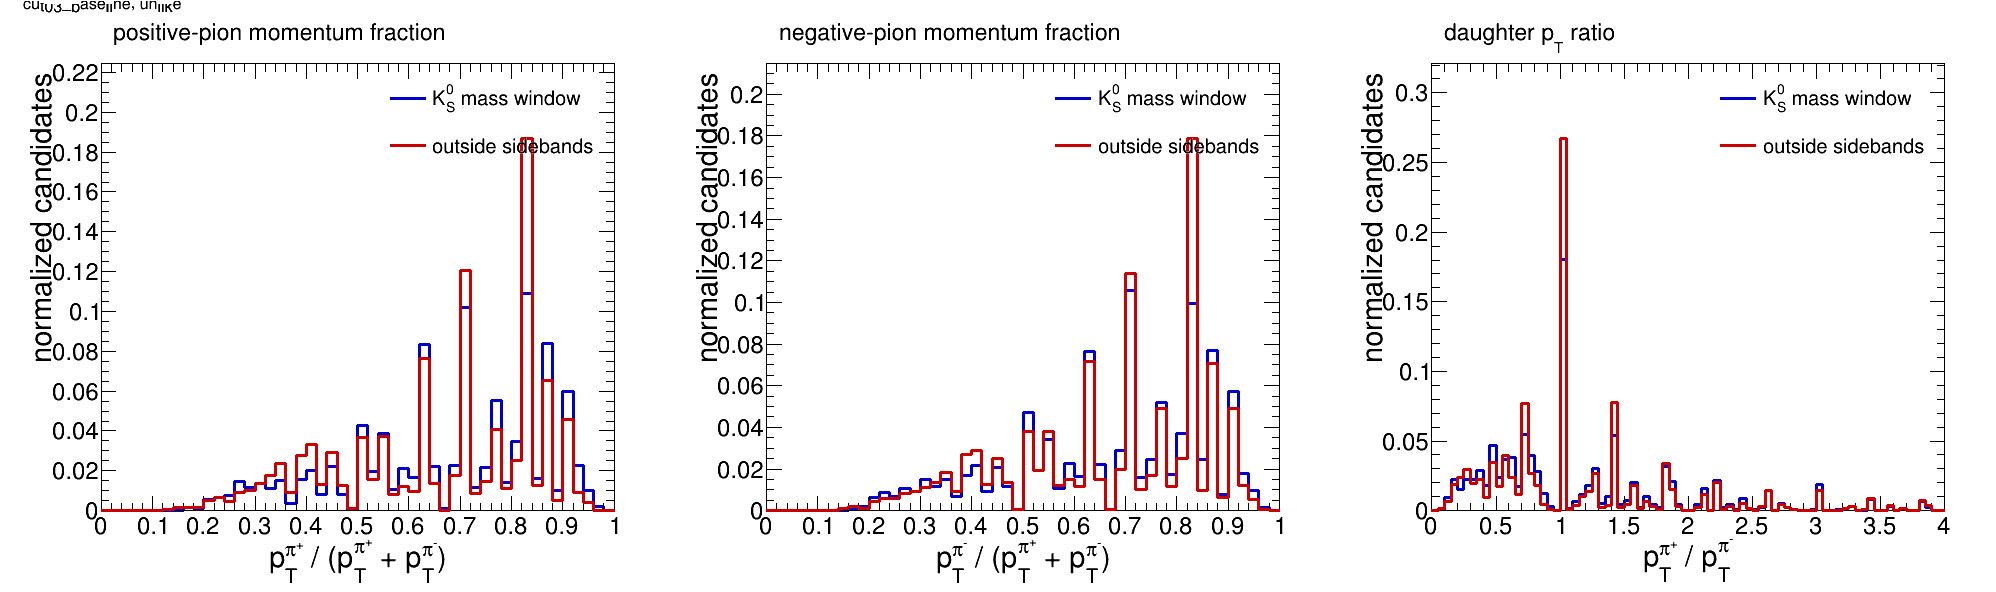

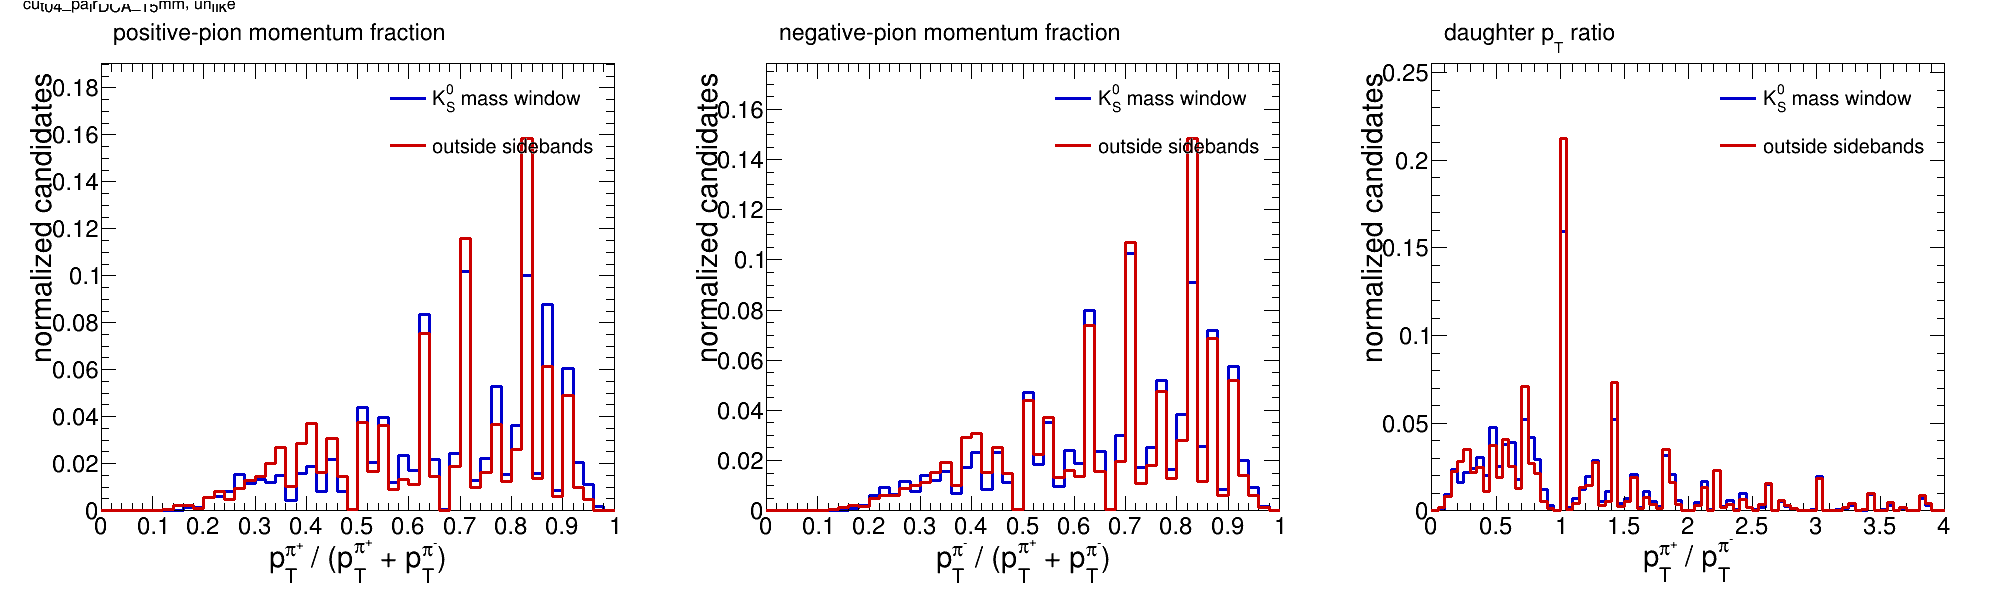

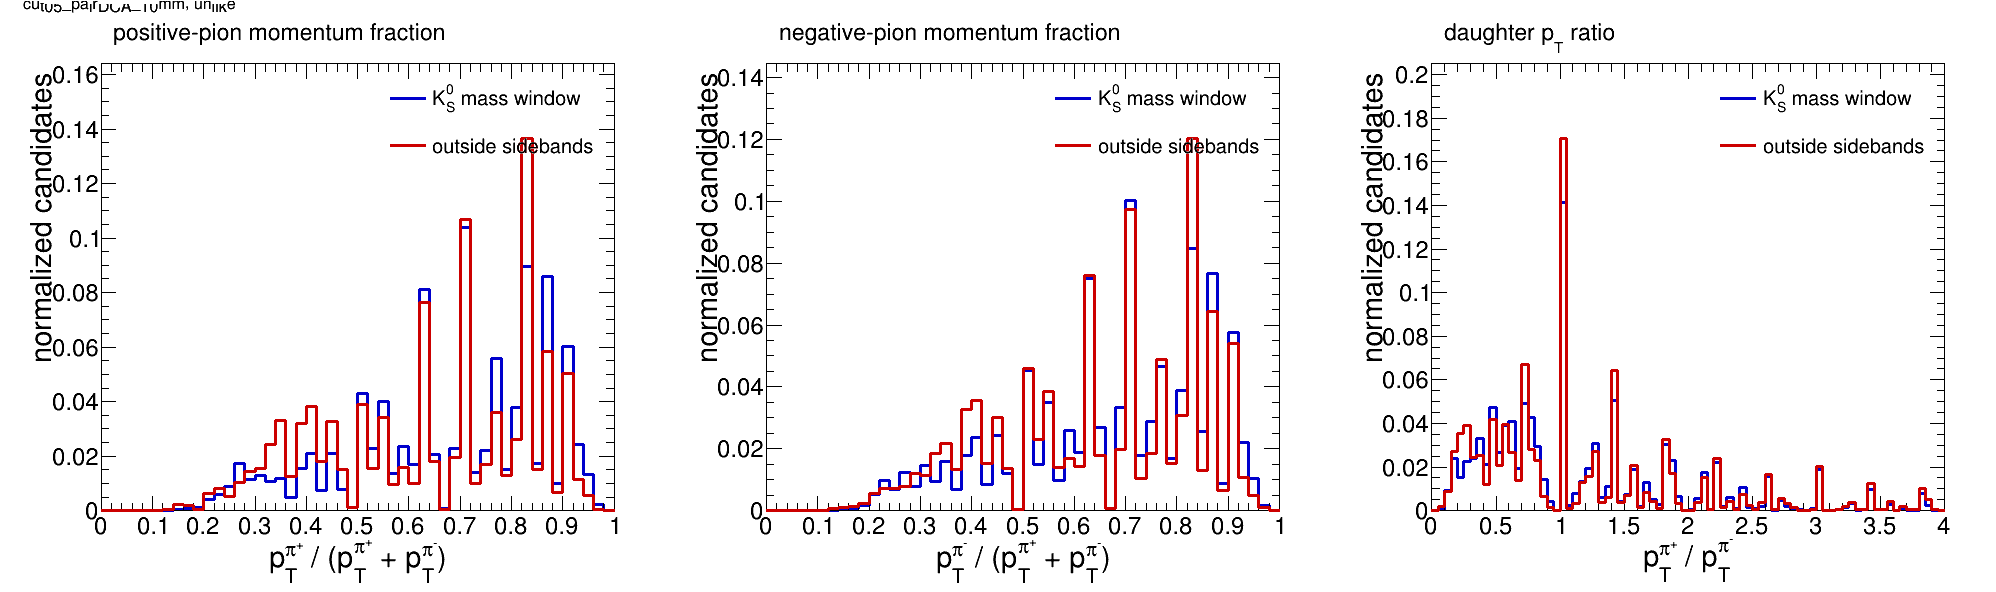

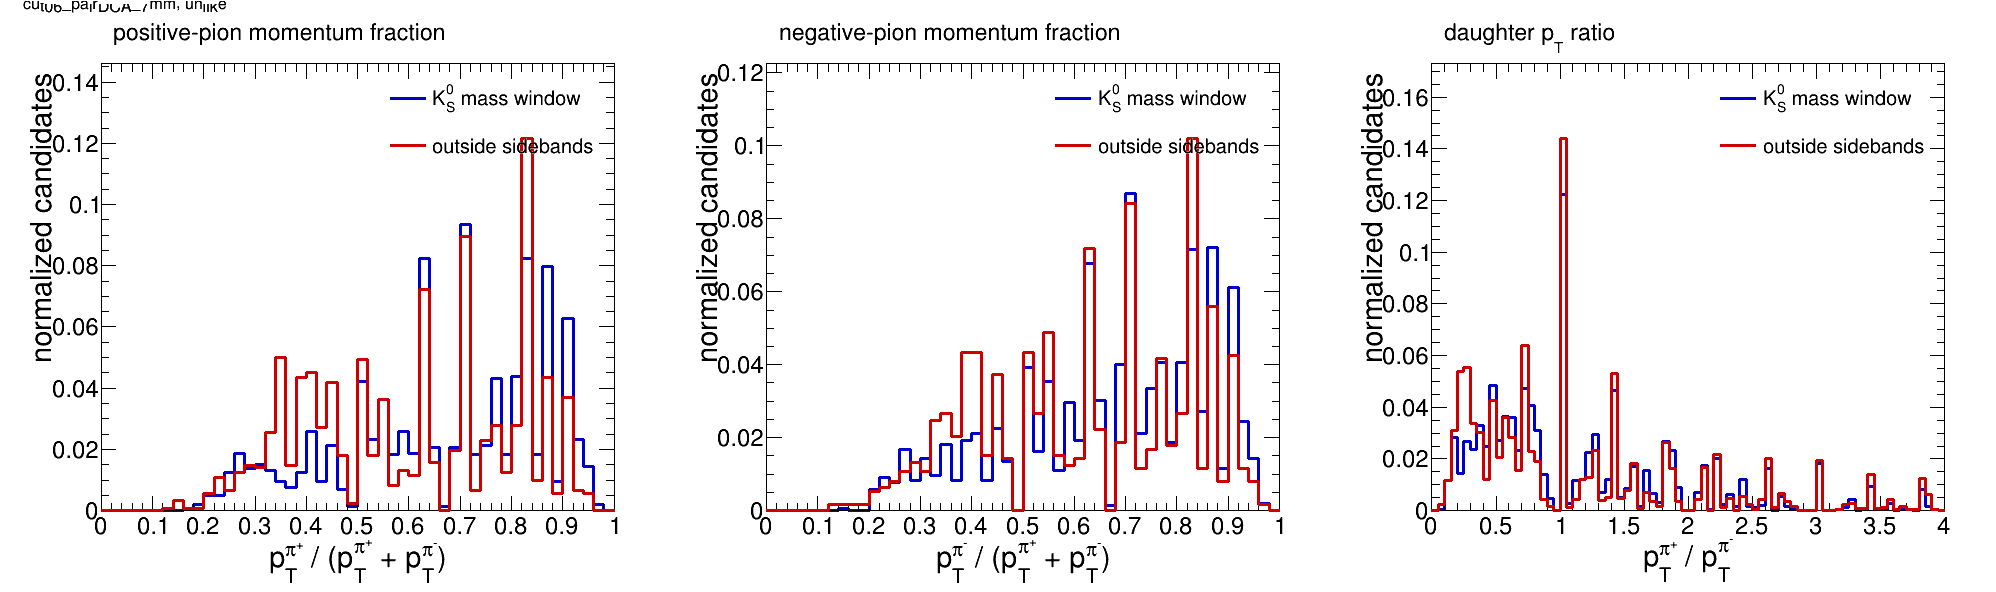

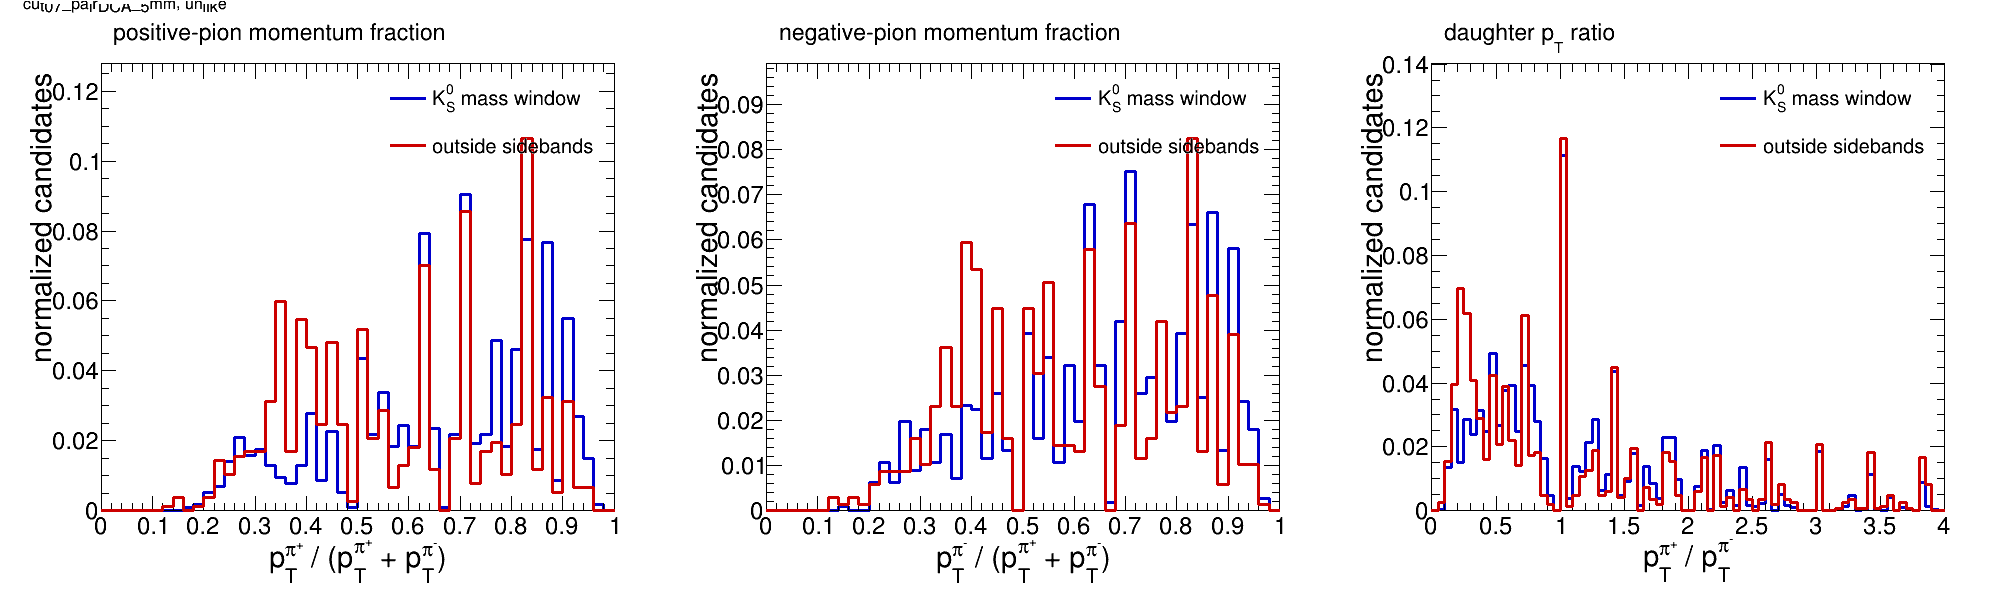

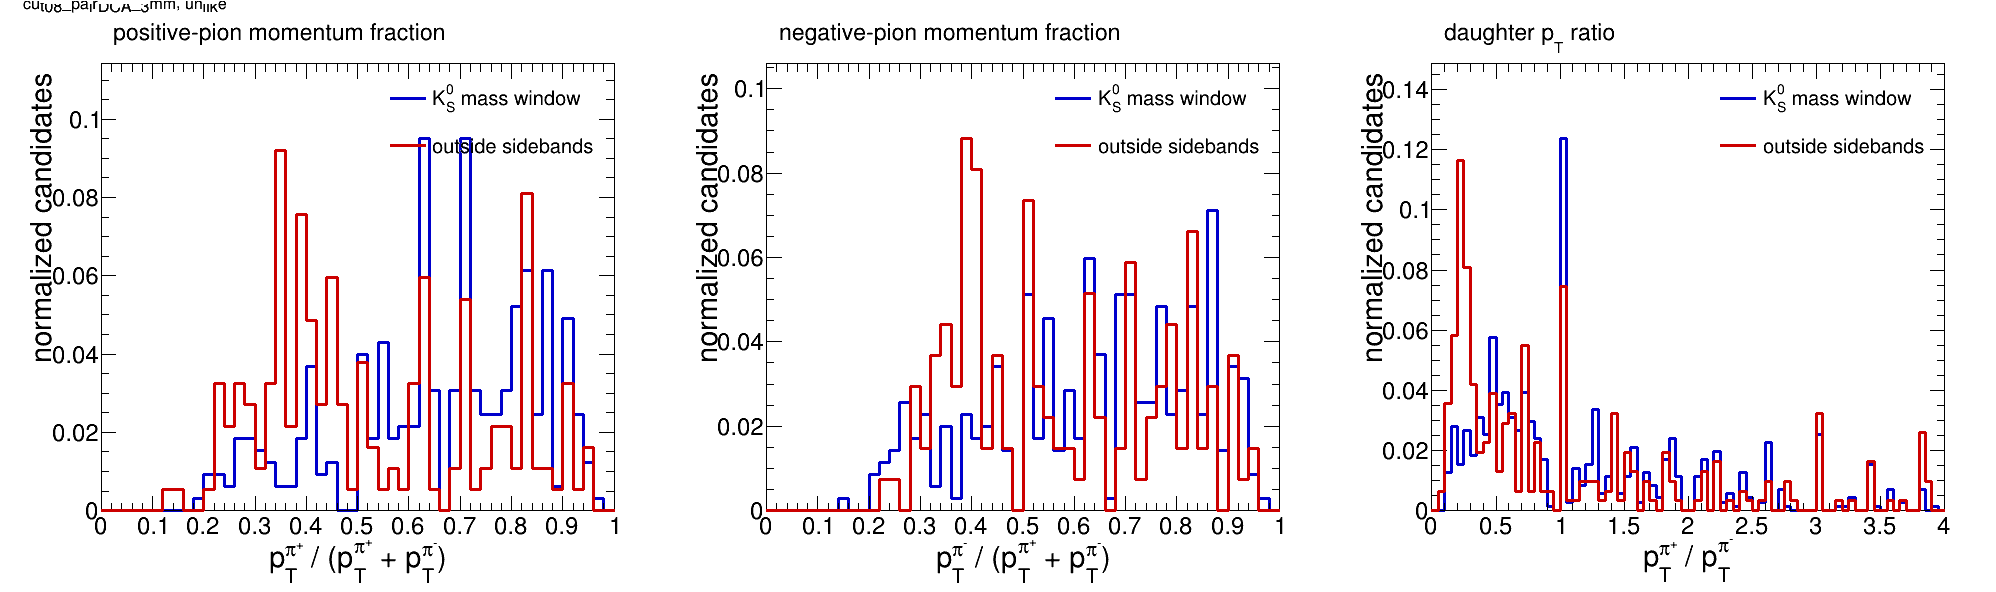

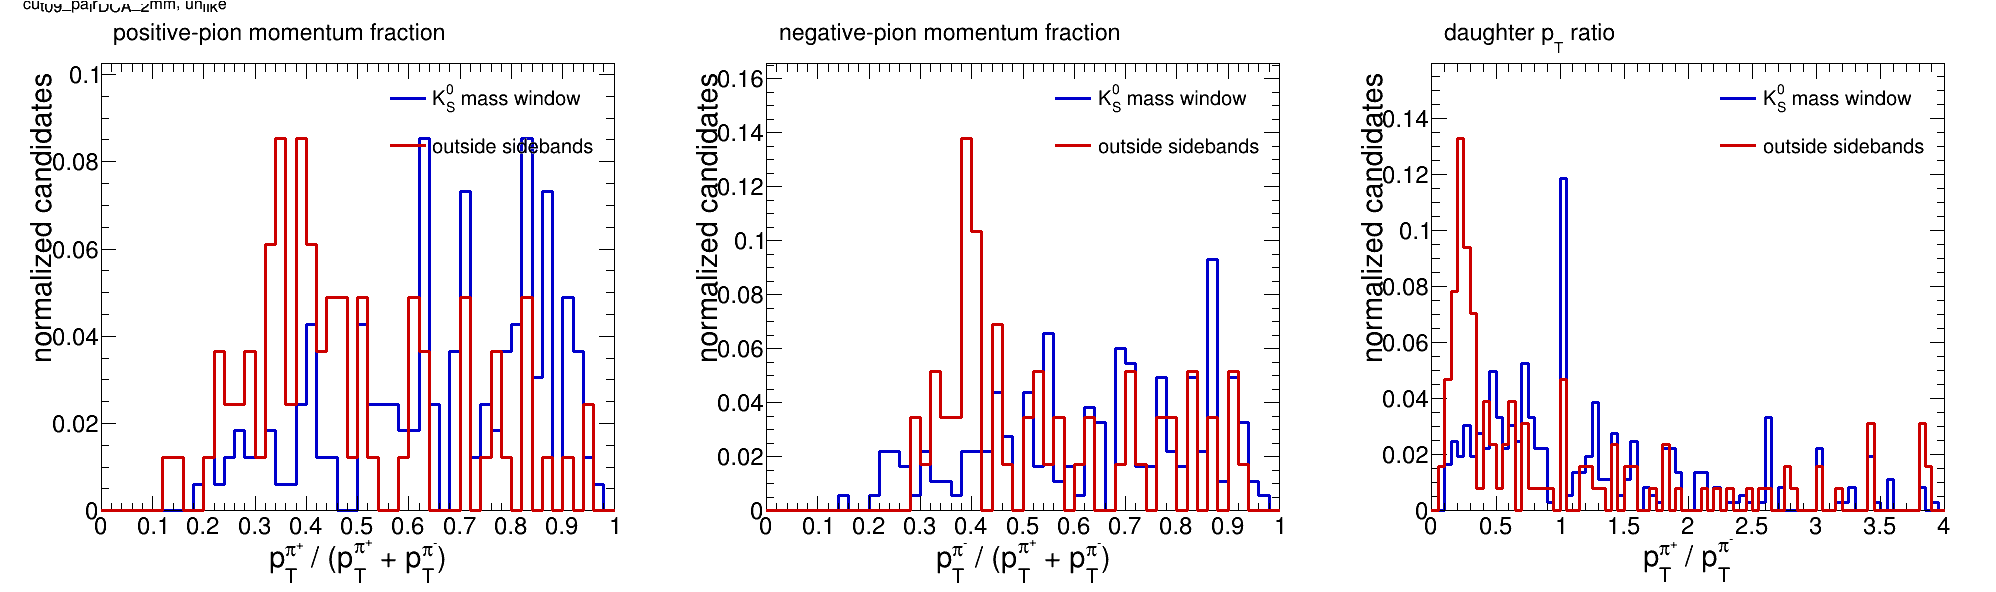

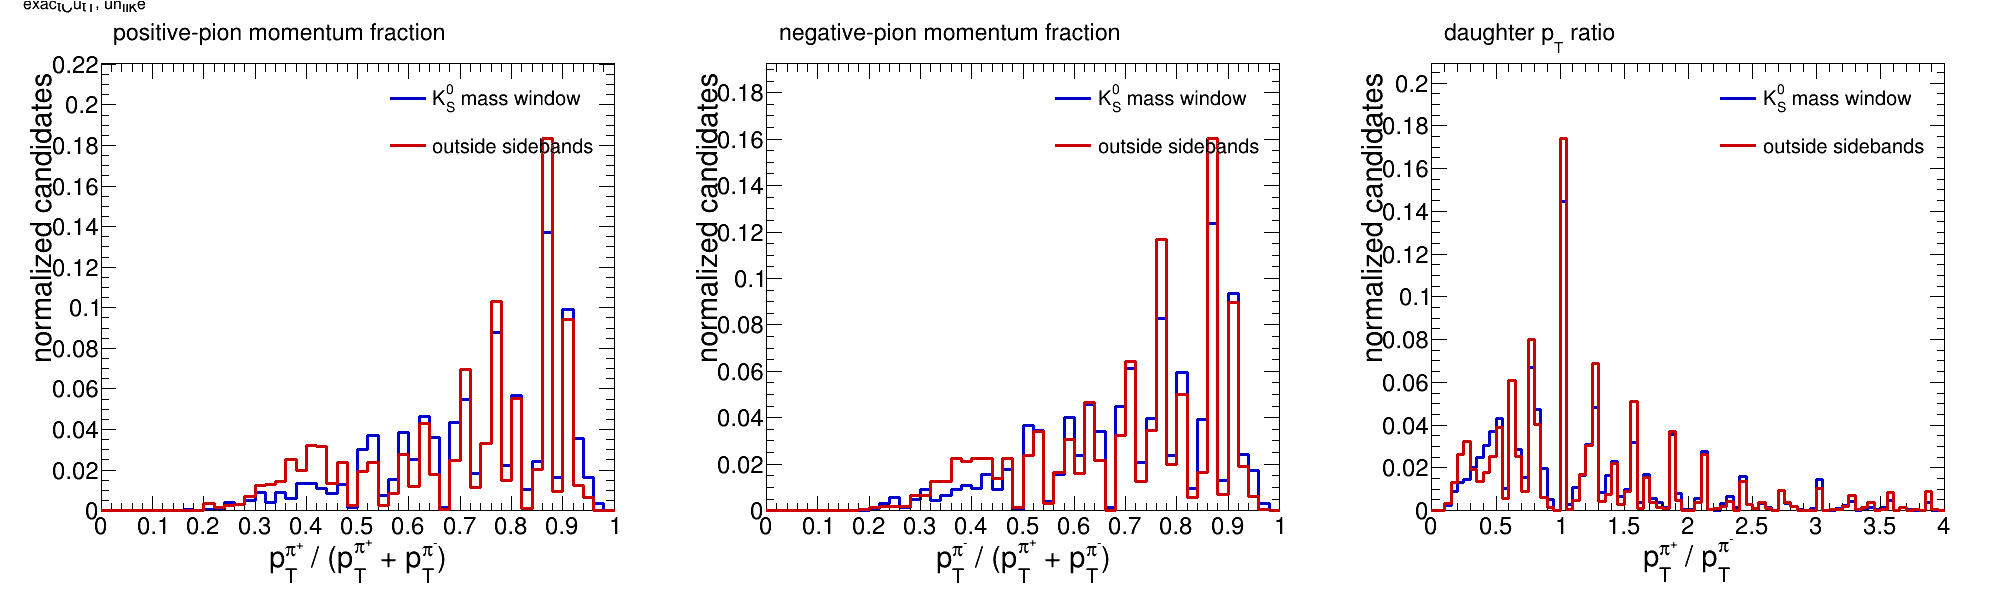

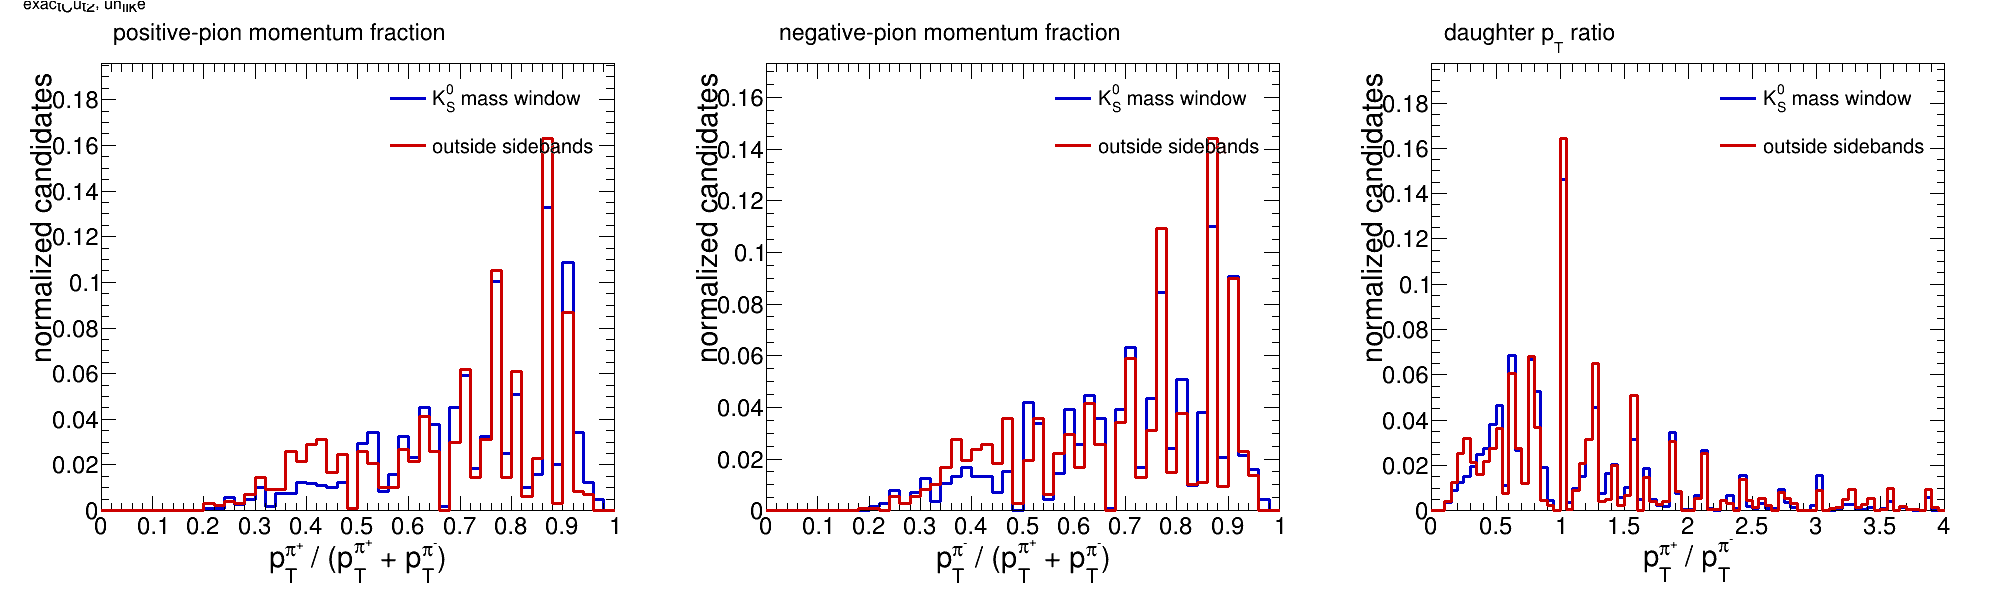

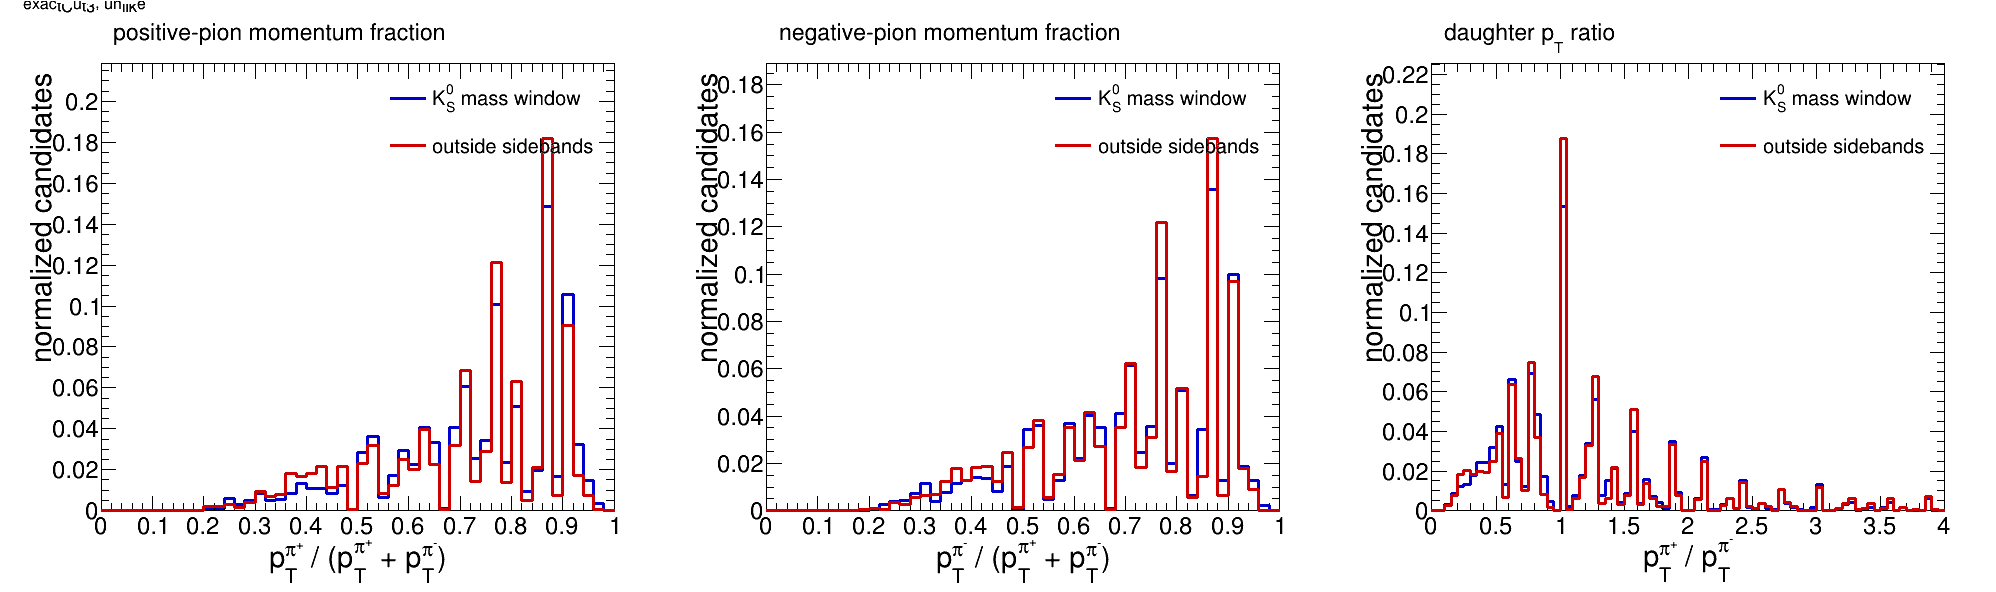

In [14]:
sharing_canvases = []
sharing_pdf = str(
    Path(output_dir) / "K0S_daughter_momentum_sharing_all_cuts.pdf"
)

for index, result in enumerate(sharing_results):
    cut_name = result["cut"]

    canvas = keep(root.TCanvas(
        f"c_sharing_{index}",
        f"c_sharing_{index}",
        2000,
        620
    ))
    canvas.Divide(3, 1)

    canvas.cd(1)
    set_pad_1d()
    draw_inside_outside(
        result["inside"]["fplus"],
        result["outside"]["fplus"],
        "p_{T}^{#pi^{+}} / (p_{T}^{#pi^{+}} + p_{T}^{#pi^{-}})",
        "positive-pion momentum fraction"
    )

    canvas.cd(2)
    set_pad_1d()
    draw_inside_outside(
        result["inside"]["fminus"],
        result["outside"]["fminus"],
        "p_{T}^{#pi^{-}} / (p_{T}^{#pi^{+}} + p_{T}^{#pi^{-}})",
        "negative-pion momentum fraction"
    )

    canvas.cd(3)
    set_pad_1d()
    draw_inside_outside(
        result["inside"]["ptratio"],
        result["outside"]["ptratio"],
        "p_{T}^{#pi^{+}} / p_{T}^{#pi^{-}}",
        "daughter p_{T} ratio"
    )

    canvas.cd()
    title = keep(root.TLatex())
    title.SetNDC()
    title.SetTextFont(42)
    title.SetTextSize(0.030)
    title.DrawLatex(
        0.012,
        0.985,
        f"{cut_name}, {charge_name}"
    )

    canvas.Update()
    canvas.Draw()
    sharing_canvases.append(canvas)

    safe_cut = cut_name.replace("/", "_")

    if save_individual_pdf:
        canvas.SaveAs(
            str(Path(output_dir) / f"K0S_daughter_sharing_{safe_cut}.pdf")
        )

    if save_png:
        canvas.SaveAs(
            str(Path(output_dir) / f"K0S_daughter_sharing_{safe_cut}.png")
        )

    if save_multipage_pdf:
        if index == 0:
            canvas.Print(sharing_pdf + "(")
        elif index == len(sharing_results) - 1:
            canvas.Print(sharing_pdf + ")")
        else:
            canvas.Print(sharing_pdf)

print("Finished momentum-sharing QA")